#A Hybrid Customer Segmentation and Repurchase Prediction Framework Using RFMT Features and Machine Learning

**Clustering Algorithms:** K-Means, Fuzzy C-Means, Spectral Clustering, MeanShift  
**Classification Models:** Logistic Regression, Random Forest, Gradient Boosting, XGBoost.  

# 1 Data Pre-processing

### Load Dataset

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Connect to Google Drive
drive.mount('/content/drive')

# 2. File path
path_09_10 = '/content/drive/MyDrive/GIỮA KỲ_ADM/ADM_Nhom_7/online_retail_II_2009_2010.csv'
path_10_11 = '/content/drive/MyDrive/GIỮA KỲ_ADM/ADM_Nhom_7/online_retail_II_2010_2011.csv'

# 3. Read data from 2 files
df_2009_2010 = pd.read_csv(path_09_10, sep=';')
df_2010_2011 = pd.read_csv(path_10_11, sep=';')

# 4. Concatenate (Combine) 2 DataFrames row-wise
df= pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

print(f"Merge successful! Total rows: {len(df)}")

Mounted at /content/drive
Merge successful! Total rows: 1067371


In [ ]:
print(f"Original DataFrame shape (rows, columns): {df.shape}")

Original DataFrame shape (rows, columns): (1067371, 8)


### Missing Values

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with missing values and their counts:")
display(missing_values)

# Handle missing CustomerID values by dropping rows where CustomerID is null
df_cleaned = df.dropna(subset=['Customer ID'])

# Verify that CustomerID missing values have been handled
print("\nMissing values after dropping rows with null Customer ID:")
display(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape (after dropping null Customer ID): {df_cleaned.shape}")

Columns with missing values and their counts:


,0
Customer ID,243007
Description,4382



Missing values after dropping rows with null Customer ID:


,0



Original DataFrame shape: (1067371, 8)
Cleaned DataFrame shape (after dropping null Customer ID): (824364, 8)


In [ ]:
print(f"DataFrame shape before dropping duplicates: {df_cleaned.shape}")

# Drop duplicate rows
df_no_duplicates = df_cleaned.drop_duplicates()

print(f"DataFrame shape after dropping duplicates: {df_no_duplicates.shape}")

DataFrame shape before dropping duplicates: (824364, 8)
DataFrame shape after dropping duplicates: (797885, 8)


In [ ]:
print(f"DataFrame shape before removing cancelled invoices: {df_no_duplicates.shape}")

df_no_cancelled = df_no_duplicates[~df_no_duplicates['Invoice'].astype(str).str.startswith('C')]

print(f"DataFrame shape after removing cancelled invoices: {df_no_cancelled.shape}")

DataFrame shape before removing cancelled invoices: (797885, 8)
DataFrame shape after removing cancelled invoices: (779495, 8)


In [ ]:
noise_codes = {"POST","D","M","BANK CHARGES","PADS","DOT","CRUK"}
df = df[~df["StockCode"].astype(str).str.upper().isin(noise_codes)]

In [ ]:
print(f"DataFrame shape before removing negative Quantity/Price: {df_no_cancelled.shape}")

df_processed = df_no_cancelled[(df_no_cancelled['Quantity'] > 0) & (df_no_cancelled['Price'] > 0)]

print(f"DataFrame shape after removing negative Quantity/Price: {df_processed.shape}")

DataFrame shape before removing negative Quantity/Price: (779495, 8)
DataFrame shape after removing negative Quantity/Price: (779425, 8)


# 2 RFMT Feature Engineering

### Outlier Detection using IQR Method

Number of outliers in 'Quantity' using IQR method: 51119
Lower bound for Quantity: -13.0
Upper bound for Quantity: 27.0


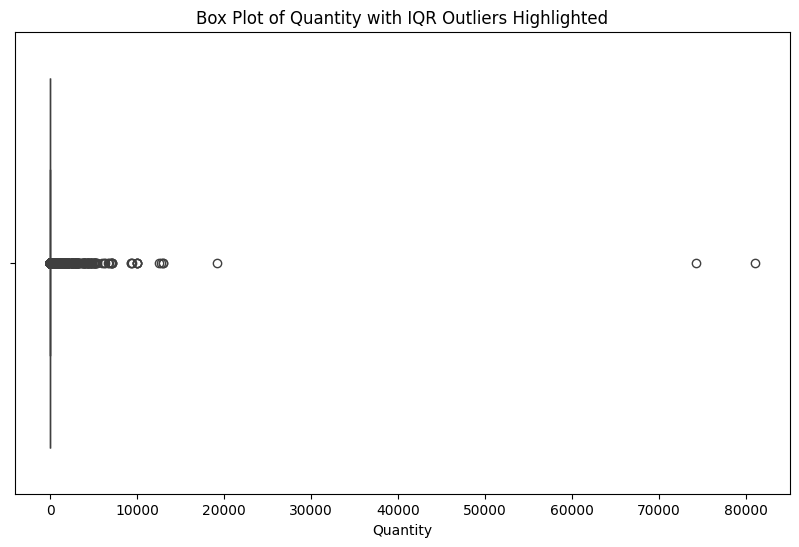

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


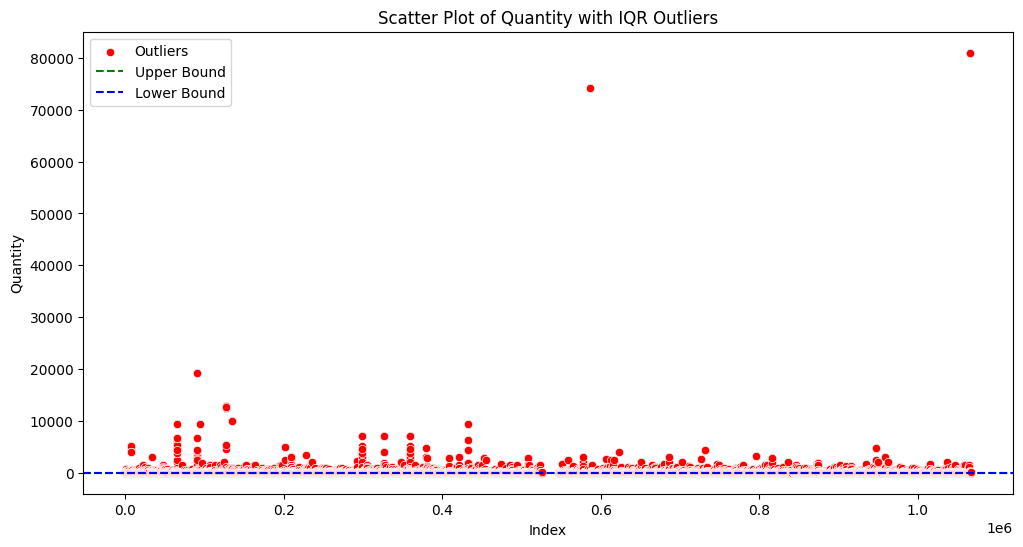

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Q1, Q3, and IQR for 'Quantity'
Q1 = df_processed['Quantity'].quantile(0.25)
Q3 = df_processed['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Identify outliers for 'Quantity'
iqr_outliers_quantity = df_processed[(df_processed['Quantity'] < lower_bound) | (df_processed['Quantity'] > upper_bound)]

print(f"Number of outliers in 'Quantity' using IQR method: {len(iqr_outliers_quantity)}")
print(f"Lower bound for Quantity: {lower_bound}")
print(f"Upper bound for Quantity: {upper_bound}")

# Visualize Quantity outliers using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_processed['Quantity']) # Changed 'y' to 'x' for horizontal plot
plt.title('Box Plot of Quantity with IQR Outliers Highlighted')
plt.xlabel('Quantity') # Changed label for x-axis
plt.show()

# Visualize Quantity outliers using a scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_processed.index, y=df_processed['Quantity'], alpha=0.6)
sns.scatterplot(x=iqr_outliers_quantity.index, y=iqr_outliers_quantity['Quantity'], color='red', label='Outliers')
plt.axhline(y=upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.axhline(y=lower_bound, color='blue', linestyle='--', label='Lower Bound')
plt.title('Scatter Plot of Quantity with IQR Outliers')
plt.xlabel('Index')
plt.ylabel('Quantity')
plt.legend()
plt.show()

### Outlier Detection using IQR Method for `Price`

Number of outliers in 'Price' using IQR method: 65463
Lower bound for Price: -2.5
Upper bound for Price: 7.5


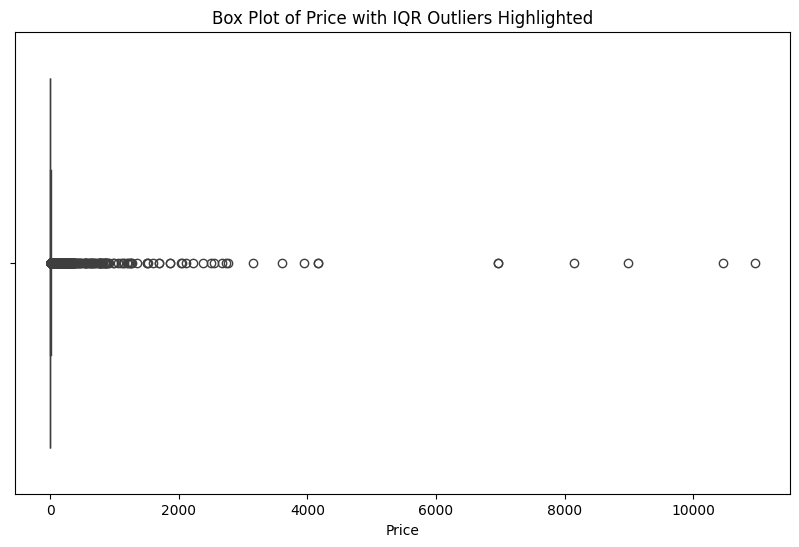

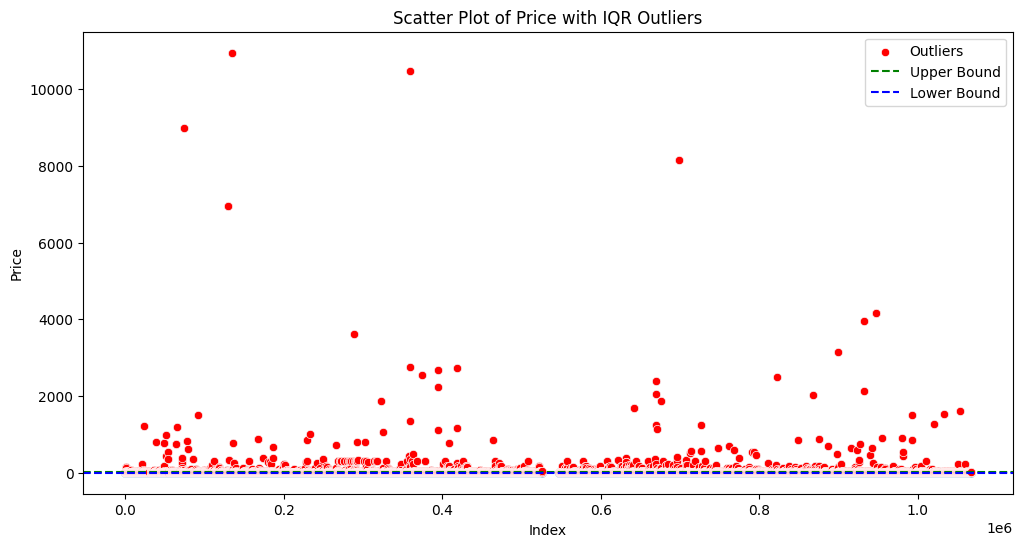

In [ ]:
# Calculate Q1, Q3, and IQR for 'Price'
Q1_price = df_processed['Price'].quantile(0.25)
Q3_price = df_processed['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Define bounds for outliers
upper_bound_price = Q3_price + 1.5 * IQR_price
lower_bound_price = Q1_price - 1.5 * IQR_price

# Identify outliers for 'Price'
iqr_outliers_price = df_processed[(df_processed['Price'] < lower_bound_price) | (df_processed['Price'] > upper_bound_price)]

print(f"Number of outliers in 'Price' using IQR method: {len(iqr_outliers_price)}")
print(f"Lower bound for Price: {lower_bound_price}")
print(f"Upper bound for Price: {upper_bound_price}")

# Visualize Price outliers using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_processed['Price'])
plt.title('Box Plot of Price with IQR Outliers Highlighted')
plt.xlabel('Price')
plt.show()

# Visualize Price outliers using a scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_processed.index, y=df_processed['Price'], alpha=0.6)
sns.scatterplot(x=iqr_outliers_price.index, y=iqr_outliers_price['Price'], color='red', label='Outliers')
plt.axhline(y=upper_bound_price, color='green', linestyle='--', label='Upper Bound')
plt.axhline(y=lower_bound_price, color='blue', linestyle='--', label='Lower Bound')
plt.title('Scatter Plot of Price with IQR Outliers')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.show()

### Outlier Treatment using Capping Method

In [ ]:
# Define function to compute outlier thresholds (using 1st and 99th percentile)
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.01)
    quartile3 = dataframe[variable].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return up_limit, low_limit

# Define function to replace outliers with threshold values
def replace_with_threshold(dataframe, variable):
    up_limit, low_limit = outlier_thresholds(dataframe, variable)
    # Cast to float if column is int64 to avoid FutureWarning
    if dataframe[variable].dtype == 'int64':
        dataframe[variable] = dataframe[variable].astype(float)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

print("Functions 'outlier_thresholds' and 'replace_with_threshold' have been defined.")

Functions 'outlier_thresholds' and 'replace_with_threshold' have been defined.


In [ ]:
# Apply outlier treatment to 'Quantity' and 'Price'
replace_with_threshold(df_processed, "Quantity")
replace_with_threshold(df_processed, "Price")

print("Outlier treatment applied to 'Quantity' and 'Price' columns.")

Outlier treatment applied to 'Quantity' and 'Price' columns.


/tmp/ipykernel_822/6138439.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[variable] = dataframe[variable].astype(float)


### Distribution After Outlier Treatment

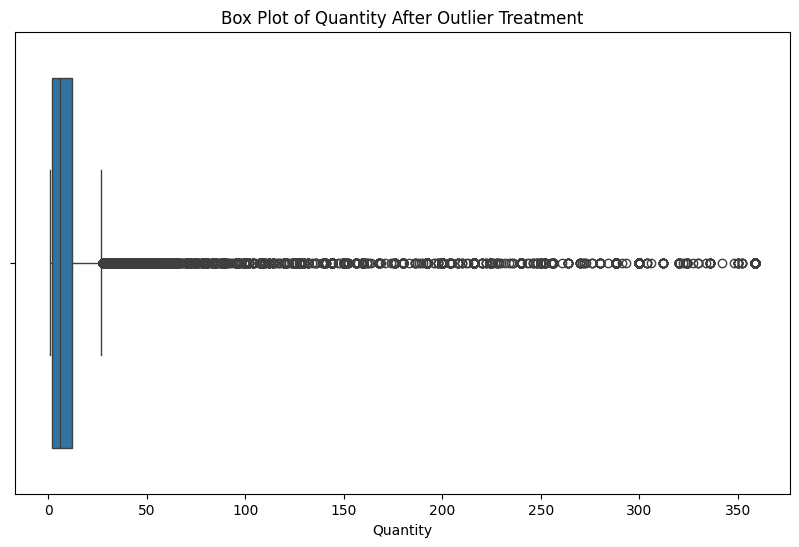

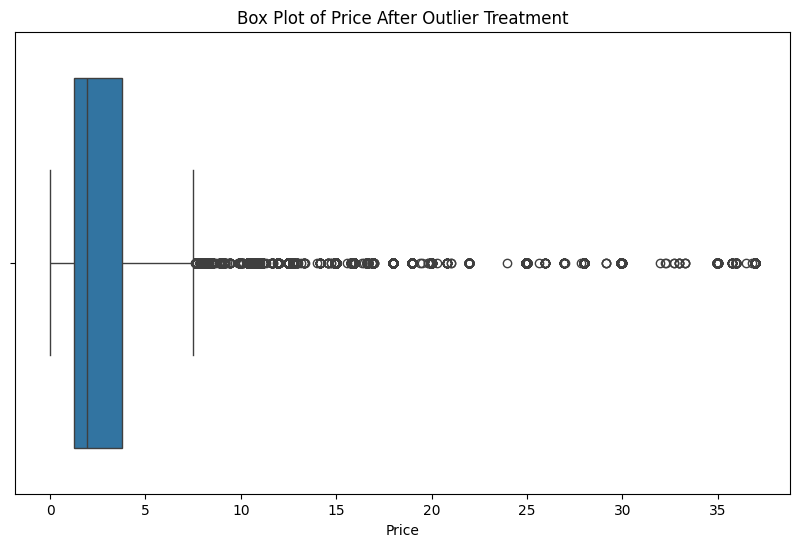

In [ ]:
# Visualize Quantity after outlier treatment using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_processed['Quantity'])
plt.title('Box Plot of Quantity After Outlier Treatment')
plt.xlabel('Quantity')
plt.show()

# Visualize Price after outlier treatment using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_processed['Price'])
plt.title('Box Plot of Price After Outlier Treatment')
plt.xlabel('Price')
plt.show()

### Verify Row Count After Processing

In [ ]:
print(f"DataFrame shape after cleaning and outlier treatment: {df_processed.shape}")

DataFrame shape after cleaning and outlier treatment: (779425, 8)


### Compute RFMT (Recency, Frequency, Monetary, Inter-purchase Interval)

In [ ]:
import datetime as dt

# 1. Create TotalPrice column
df_processed.loc[:, 'TotalPrice'] = df_processed['Quantity'] * df_processed['Price']

# 2. Convert InvoiceDate to datetime
df_processed.loc[:, 'InvoiceDate'] = pd.to_datetime(df_processed['InvoiceDate'], format='%d.%m.%Y %H:%M')

# 3. Define reference date (Analysis Date) as last date in dataset + 1 day
analysis_date = df_processed['InvoiceDate'].max() + dt.timedelta(days=1)

# 4. Group by CustomerID to compute R, F, M and time anchors T1, Tn
rfmt = df_processed.groupby('Customer ID').agg({
    'InvoiceDate': [lambda date: (analysis_date - date.max()).days, # Recency
                    lambda date: date.min(),                        # T1 (First purchase)
                    lambda date: date.max()],                       # Tn (Last purchase)
    'Invoice': 'nunique',                                         # Frequency
    'TotalPrice': 'sum'                                             # Monetary
})

# Rename columns for clarity
rfmt.columns = ['Recency', 'T1', 'Tn', 'Frequency', 'Monetary']

rfmt = rfmt.reset_index()

# 5. Compute T (Inter-purchase interval)
# Formula: T = (Tn - T1) / (F - 1). If F=1, T = Recency
def calculate_t(row):
    if row['Frequency'] > 1:
        # Compute number of days between Tn and T1
        diff_days = (row['Tn'] - row['T1']).days
        return diff_days / (row['Frequency'] - 1)
    else:
        return row['Recency']

rfmt['T'] = rfmt.apply(calculate_t, axis=1)

# Drop auxiliary columns T1, Tn
rfmt_final = rfmt[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'T']]

# Display result
print("RFMT DataFrame summary:")
display(rfmt_final.head())
print(f"\nShape of RFMT data: {rfmt_final.shape}")

/tmp/ipykernel_822/1695413741.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed.loc[:, 'TotalPrice'] = df_processed['Quantity'] * df_processed['Price']


RFMT DataFrame summary:


,Customer ID,Recency,Frequency,Monetary,T
0,12346.0,326,12,745.70,36.363636
1,12347.0,2,8,4921.53,57.428571
2,12348.0,75,5,1991.86,90.500000
3,12349.0,19,4,3786.50,190.000000
4,12350.0,310,1,331.34,310.000000



Shape of RFMT data: (5878, 5)


### 💾 Save: rfmt_features.csv

In [ ]:
# 💾 Export: rfmt_features.csv
# RFMT features (before outlier capping)
import os
_save_dir = '/content/drive/MyDrive/GIỮA KỲ_ADM/Data'
os.makedirs(_save_dir, exist_ok=True)
_path = os.path.join(_save_dir, 'rfmt_features.csv')
rfmt_final.to_csv(_path, index=False)
print(f'Saved rfmt_final → {_path}  ({len(rfmt_final):,} rows)')


Saved rfmt_final → /content/drive/MyDrive/GIỮA KỲ_ADM/Data/rfmt_features.csv  (5,878 rows)


### Check & Handle RFMT Outliers

### RFMT Outlier Inspection
Before clustering, we need to examine the distribution of Recency, Frequency, Monetary, and T.

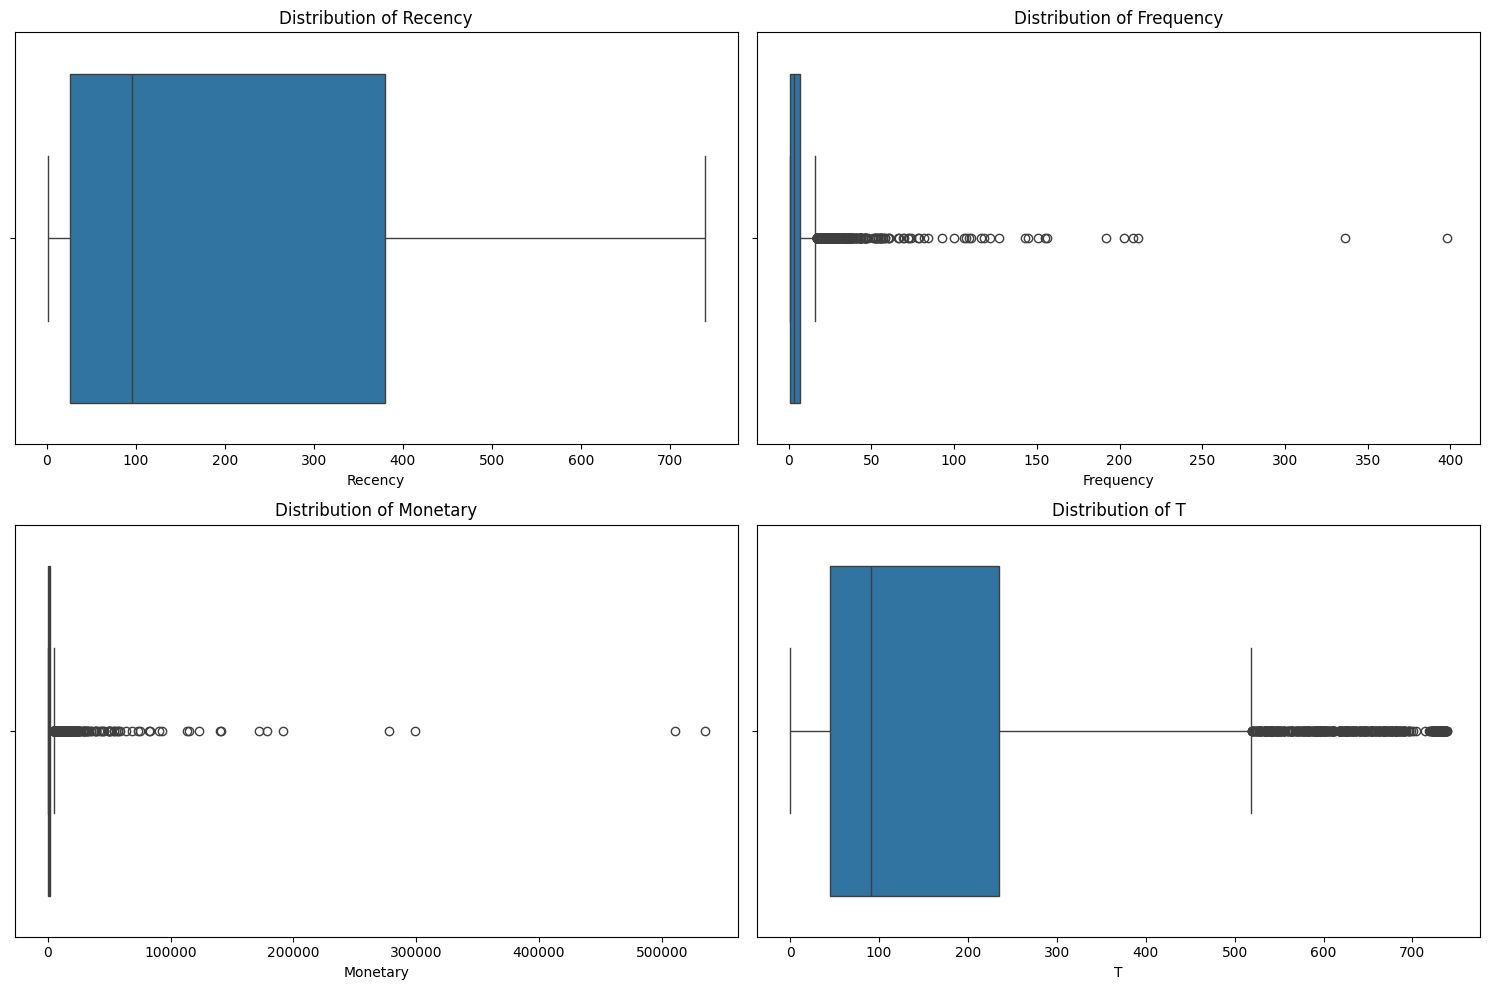

,Recency,Frequency,Monetary,T
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2780.247035,171.973198
std,209.338707,13.009406,13301.753016,184.390353
min,1.000000,1.000000,2.950000,0.000000
5%,4.000000,1.000000,110.186000,13.000000
25%,26.000000,1.000000,337.265000,45.000000
50%,96.000000,3.000000,848.680000,90.645833
75%,380.000000,7.000000,2216.357500,234.500000
95%,625.000000,21.000000,8901.556500,606.150000
99%,726.000000,46.000000,25779.656800,725.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to inspect
features = ['Recency', 'Frequency', 'Monetary', 'T']

# Draw boxplot to visualise outliers
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=rfmt_final[feature])
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

# Display descriptive statistics
display(rfmt_final[features].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

### RFMT Outlier Treatment via Capping

In [ ]:
# Create a copy for processing
rfmt_cleaned = rfmt_final.copy()

# Apply the replace_with_threshold function defined above to RFMT variables
for col in ['Recency', 'Frequency', 'Monetary', 'T']:
    replace_with_threshold(rfmt_cleaned, col)

print("Outlier treatment applied to RFMT variables.")
# Re-check statistics after treatment
display(rfmt_cleaned[['Recency', 'Frequency', 'Monetary', 'T']].describe())

Outlier treatment applied to RFMT variables.


,Recency,Frequency,Monetary,T
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,201.331916,6.105903,2416.054668,171.973198
std,209.338707,10.045547,5696.369844,184.390353
min,1.000000,1.000000,2.950000,0.000000
25%,26.000000,1.000000,337.265000,45.000000
50%,96.000000,3.000000,848.680000,90.645833
75%,380.000000,7.000000,2216.357500,234.500000
max,739.000000,113.500000,64393.732000,739.000000


### EDA: RFMT Distribution After Outlier Treatment (Before Standardisation)
Inspect the distribution shape of each RFMT variable after capping, including histogram, KDE, boxplot, and correlation matrix — to assess skewness and confirm data is ready for standardisation.
- Note: Skewness of R, F, M, T exceeds acceptable range (±1) → StandardScaler normalisation recommended

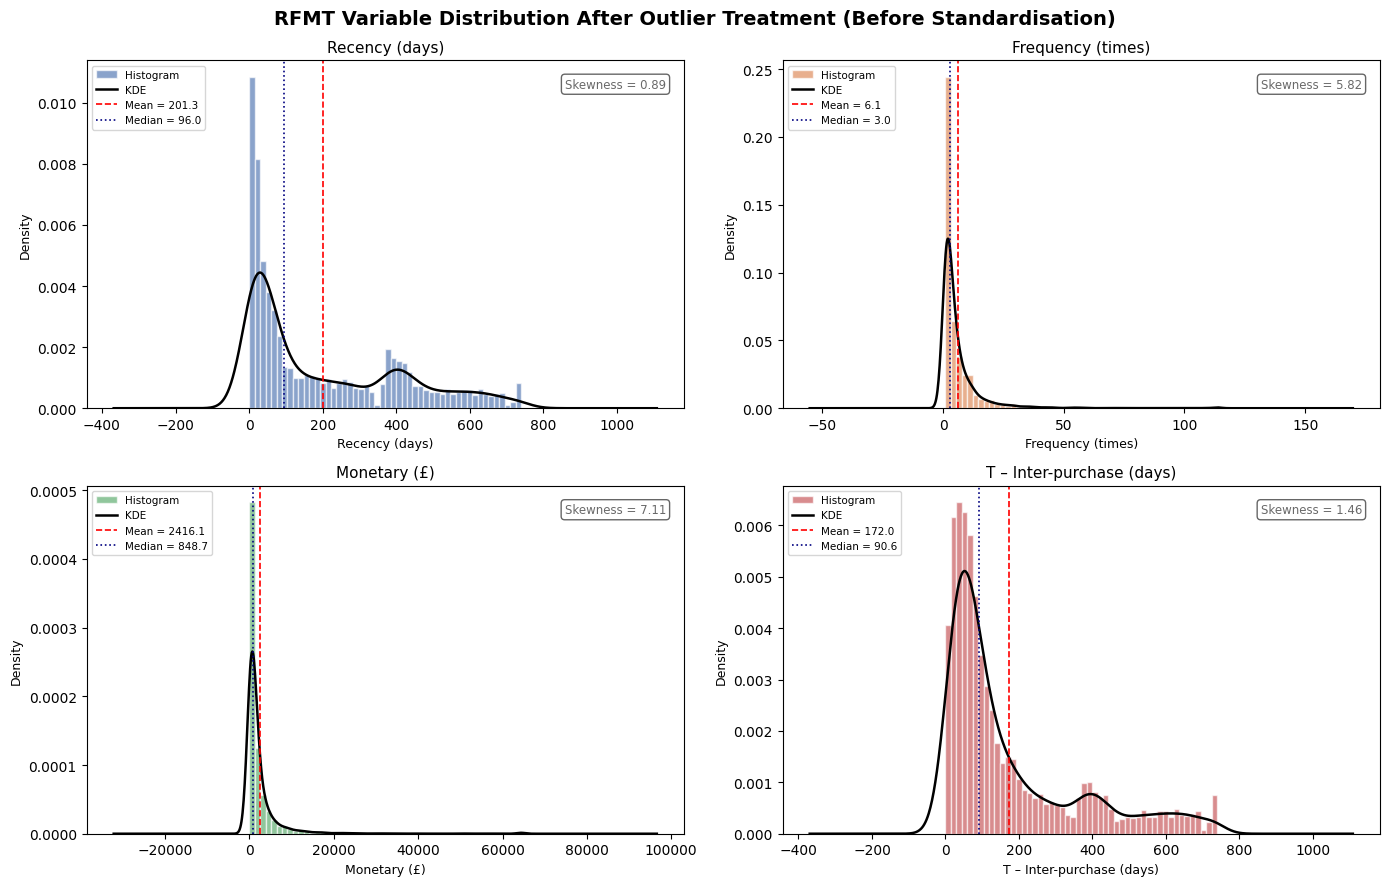


RFMT VARIABLE DESCRIPTIVE STATISTICS AFTER OUTLIER TREATMENT


,Recency,Frequency,Monetary,T
count,5878.00,5878.00,5878.00,5878.00
mean,201.33,6.11,2416.05,171.97
std,209.34,10.05,5696.37,184.39
min,1.00,1.00,2.95,0.00
5%,4.00,1.00,110.19,13.00
25%,26.00,1.00,337.26,45.00
50%,96.00,3.00,848.68,90.65
75%,380.00,7.00,2216.36,234.50
95%,625.00,21.00,8901.56,606.15
99%,726.00,46.00,25779.66,725.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = ['Recency', 'Frequency', 'Monetary', 'T']
labels_vn = {
    'Recency'   : 'Recency (days)',
    'Frequency' : 'Frequency (times)',
    'Monetary'  : 'Monetary (£)',
    'T'         : 'T – Inter-purchase (days)',
}
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── 1. Histogram + KDE ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('RFMT Variable Distribution After Outlier Treatment (Before Standardisation)',
             fontsize=14, fontweight='bold')
for ax, feat, clr in zip(axes.flatten(), features, colors):
    data = rfmt_cleaned[feat].dropna()
    ax.hist(data, bins=50, color=clr, alpha=0.65, edgecolor='white',
            density=True, label='Histogram')
    data.plot.kde(ax=ax, color='black', linewidth=1.8, label='KDE')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2,
               label=f'Mean = {data.mean():.1f}')
    ax.axvline(data.median(), color='navy',   linestyle=':',  linewidth=1.2,
               label=f'Median = {data.median():.1f}')
    ax.set_title(labels_vn[feat], fontsize=11)
    ax.set_xlabel(labels_vn[feat], fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    skew = data.skew()
    ax.text(0.97, 0.95, f'Skewness = {skew:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='dimgray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

# ── 2. Descriptive statistics table ────────────────────────────────────────
print("\n" + "="*60)
print("RFMT VARIABLE DESCRIPTIVE STATISTICS AFTER OUTLIER TREATMENT")
print("="*60)
desc = rfmt_cleaned[features].describe(percentiles=[.05,.25,.5,.75,.95,.99])
desc.loc['skewness'] = rfmt_cleaned[features].skew()
desc.loc['kurtosis'] = rfmt_cleaned[features].kurt()
display(desc.round(2))


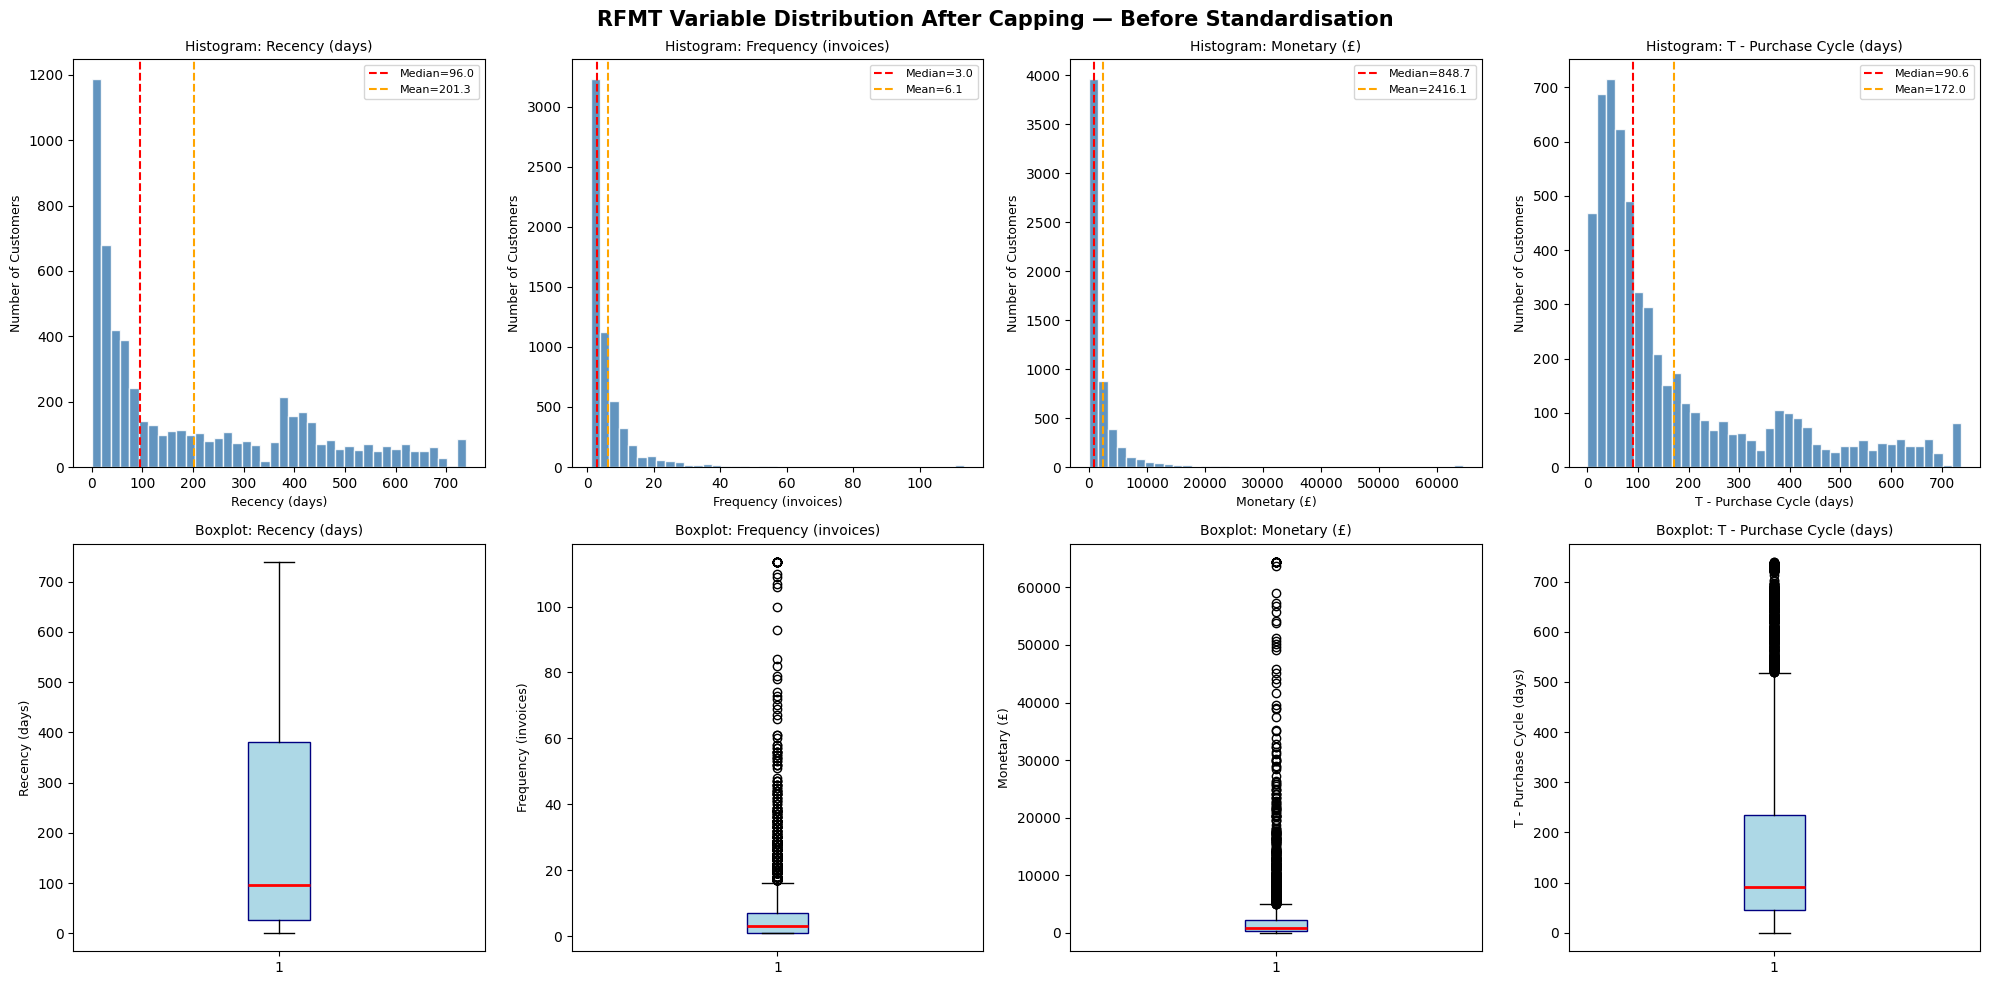


=== RFMT Descriptive Statistics After Capping ===


,Recency,Frequency,Monetary,T
count,5878.00,5878.00,5878.00,5878.00
mean,201.33,6.11,2416.05,171.97
std,209.34,10.05,5696.37,184.39
min,1.00,1.00,2.95,0.00
5%,4.00,1.00,110.19,13.00
25%,26.00,1.00,337.26,45.00
50%,96.00,3.00,848.68,90.65
75%,380.00,7.00,2216.36,234.50
95%,625.00,21.00,8901.56,606.15
99%,726.00,46.00,25779.66,725.00



=== Skewness & Kurtosis After Capping ===
  Recency     : skewness= 0.887, kurtosis= -0.478
  Frequency   : skewness= 5.816, kurtosis= 48.244
  Monetary    : skewness= 7.113, kurtosis= 63.875
  T           : skewness= 1.460, kurtosis=  1.127


In [ ]:
# ── EDA: RFMT after outlier capping, before standardisation ────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = ['Recency', 'Frequency', 'Monetary', 'T']
feature_labels = ['Recency (days)', 'Frequency (invoices)', 'Monetary (£)', 'T - Purchase Cycle (days)']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('RFMT Variable Distribution After Capping — Before Standardisation', fontsize=15, fontweight='bold')

for i, (feat, label) in enumerate(zip(features, feature_labels)):
    data = rfmt_cleaned[feat].dropna()
    # Histogram
    axes[0, i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
                        label=f'Median={data.median():.1f}')
    axes[0, i].axvline(data.mean(),   color='orange', linestyle='--', linewidth=1.5,
                        label=f'Mean={data.mean():.1f}')
    axes[0, i].set_title(f'Histogram: {label}', fontsize=10)
    axes[0, i].set_xlabel(label, fontsize=9)
    axes[0, i].set_ylabel('Number of Customers', fontsize=9)
    axes[0, i].legend(fontsize=8)
    # Boxplot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'Boxplot: {label}', fontsize=10)
    axes[1, i].set_ylabel(label, fontsize=9)

plt.tight_layout()
plt.show()

print('\n=== RFMT Descriptive Statistics After Capping ===')
display(rfmt_cleaned[features].describe(percentiles=[.05,.25,.5,.75,.95,.99]).round(2))

# Skewness & Kurtosis
from scipy import stats
print('\n=== Skewness & Kurtosis After Capping ===')
for feat in features:
    sk = stats.skew(rfmt_cleaned[feat].dropna())
    ku = stats.kurtosis(rfmt_cleaned[feat].dropna())
    print(f'  {feat:12s}: skewness={sk:6.3f}, kurtosis={ku:7.3f}')


#3 Modelling

## 3.1 Clustering

### Standardisation and Clustering
Use StandardScaler to normalise variables to standard scale before running clustering algorithms.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Standardise the data
features = ['Recency', 'Frequency', 'Monetary', 'T']
scaler = StandardScaler()
rfmt_scaled = scaler.fit_transform(rfmt_cleaned[features])

In [ ]:
pip install yellowbrick

In [ ]:
!pip install scikit-fuzzy

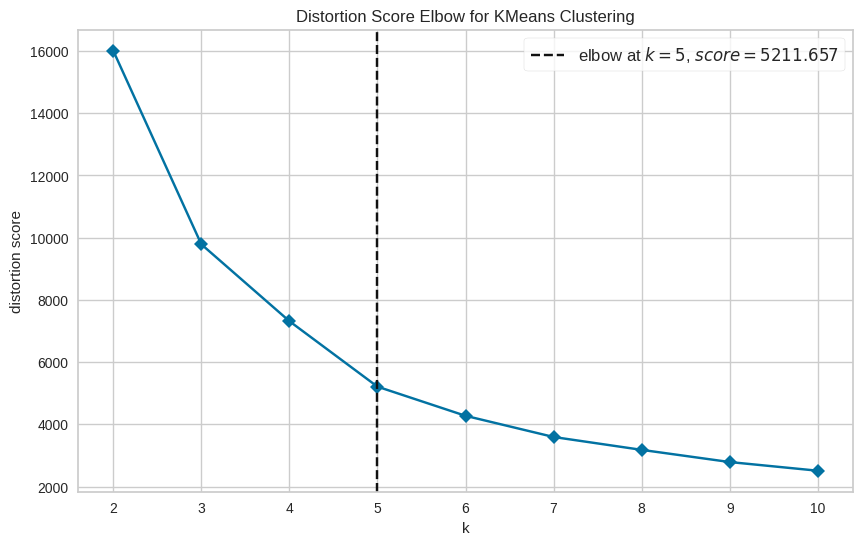

Optimal K (Elbow Method): 5


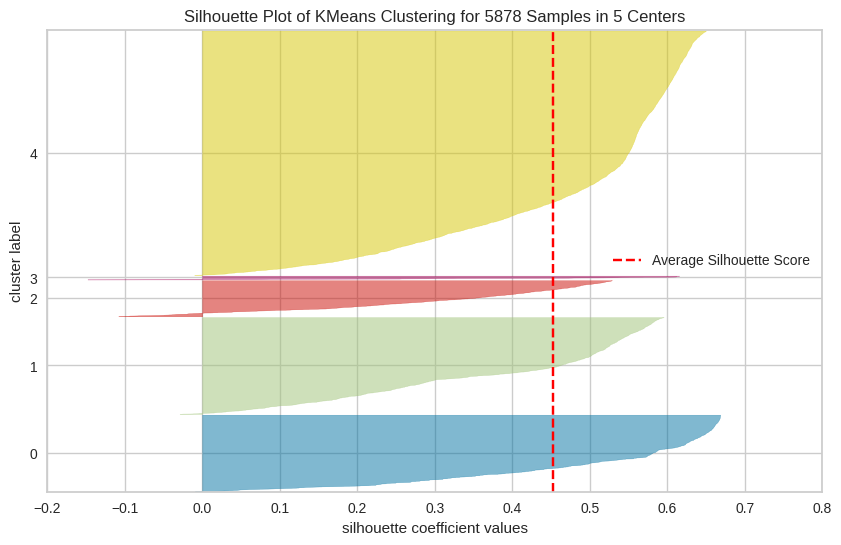

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.preprocessing import StandardScaler

# Ensure rfmt_scaled is defined (re-run from previous cell if necessary or define here for robustness)
# This is a defensive re-definition in case previous cells were not run sequentially.
features = ['Recency', 'Frequency', 'Monetary', 'T']
scaler = StandardScaler()
rfmt_scaled = scaler.fit_transform(rfmt_cleaned[features])

# Prepare the K-Means model
model = KMeans(random_state=42, n_init=10)

# Use KElbowVisualizer to find the optimal K based on inertia (Elbow Method)
plt.figure(figsize=(10, 6))
elbow_visualizer = KElbowVisualizer(model, k=(2,11), metric='distortion', timings=False)
elbow_visualizer.fit(rfmt_scaled)
elbow_visualizer.show()

optimal_k = elbow_visualizer.elbow_value_
print(f"Optimal K (Elbow Method): {optimal_k}")

# Use SilhouetteVisualizer for the optimal K
if optimal_k is not None and optimal_k > 1:
    plt.figure(figsize=(10, 6))
    silhouette_visualizer = SilhouetteVisualizer(KMeans(optimal_k, random_state=42, n_init=10), colors='yellowbrick')
    silhouette_visualizer.fit(rfmt_scaled)
    silhouette_visualizer.show()
else:
    print("Cannot visualize Silhouette for K=1 or None.")


In [ ]:
import skfuzzy as fuzz
from sklearn.cluster import SpectralClustering, MeanShift, estimate_bandwidth

k_clusters = optimal_k

# 1. K-Means
kmeans = KMeans(n_clusters=k_clusters, init='k-means++', random_state=42, n_init=10)
rfmt_cleaned['KMeans_Cluster'] = kmeans.fit_predict(rfmt_scaled)

# 2. Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    rfmt_scaled.T, k_clusters, 2, error=0.005, maxiter=1000, init=None)
rfmt_cleaned['Fuzzy_Cluster'] = np.argmax(u, axis=0)

# 3. Spectral Clustering
spectral = SpectralClustering(n_clusters=k_clusters, affinity='nearest_neighbors',
                               n_neighbors=45, random_state=42)
rfmt_cleaned['Spectral_Cluster'] = spectral.fit_predict(rfmt_scaled)

# 4. Mean Shift
# estimate_bandwidth may return None or error if there are insufficient data points for a cluster
# Handle this by providing a default value or checking for None
bandwidth = estimate_bandwidth(rfmt_scaled, quantile=0.9, n_samples=min(len(rfmt_scaled), 500))

# If bandwidth is None (e.g. when n_samples < n_features + 1), handle it
if bandwidth is None:
    print("Warning: Could not estimate bandwidth for Mean Shift, using default value.")
    # Choose a reasonable default or skip Mean Shift if bandwidth cannot be estimated
    bandwidth = 1.0 # Example default value — adjust as needed

    # Alternatively, add a check to only run Mean Shift if bandwidth is valid
    # if bandwidth is not None:
    #    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    # else:
    #    print("Skip Mean Shift: bandwidth could not be estimated.")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
rfmt_cleaned['MeanShift_Cluster'] = ms.fit_predict(rfmt_scaled)

print("Clustering completed with 4 algorithms.")
display(rfmt_cleaned.head())

Clustering completed with 4 algorithms.


,Customer ID,Recency,Frequency,Monetary,T,KMeans_Cluster,Fuzzy_Cluster,Spectral_Cluster,MeanShift_Cluster
0,12346.0,326.0,12.0,745.70,36.363636,1,0,0,0
1,12347.0,2.0,8.0,4921.53,57.428571,4,3,4,0
2,12348.0,75.0,5.0,1991.86,90.500000,4,3,0,0
3,12349.0,19.0,4.0,3786.50,190.000000,4,3,0,0
4,12350.0,310.0,1.0,331.34,310.000000,1,0,0,0


### 💾 Save: clustered_customers.csv

In [ ]:
# ── Export 2/3: clustered_customers.csv ─────────────────────────────────
import os
_save_dir = '/content/drive/MyDrive/GIỮA KỲ_ADM/Data'
os.makedirs(_save_dir, exist_ok=True)

_path = os.path.join(_save_dir, 'clustered_customers.csv')
rfmt_cleaned.to_csv(_path, index=False)
print(f'✅ clustered_customers.csv  →  {_path}')
print(f'   Shape: {rfmt_cleaned.shape}  |  Columns: {list(rfmt_cleaned.columns)}')


✅ clustered_customers.csv  →  /content/drive/MyDrive/GIỮA KỲ_ADM/Data/clustered_customers.csv
   Shape: (5878, 9)  |  Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'T', 'KMeans_Cluster', 'Fuzzy_Cluster', 'Spectral_Cluster', 'MeanShift_Cluster']


### Clustering Algorithm Performance Comparison

In [ ]:
from sklearn.metrics import silhouette_score

algos = {
    "K-Means":       rfmt_cleaned['KMeans_Cluster'],
    "Fuzzy C-Means": rfmt_cleaned['Fuzzy_Cluster'],
    "Spectral":      rfmt_cleaned['Spectral_Cluster'],
    "MeanShift":     rfmt_cleaned['MeanShift_Cluster'],
}

comparison_metrics = []
for name, labels in algos.items():
    n_clusters = len(np.unique(labels))
    if n_clusters > 1:
        s_score = silhouette_score(rfmt_scaled, labels)
        comparison_metrics.append({
            "Algorithm":  name,
            "N_Clusters": n_clusters,
            "Silhouette": round(s_score, 4),
        })

df_comparison = pd.DataFrame(comparison_metrics)
display(df_comparison.sort_values(by="Silhouette", ascending=False))


,Algorithm,N_Clusters,Silhouette
3,MeanShift,3,0.7504
0,K-Means,5,0.4523
1,Fuzzy C-Means,5,0.4325
2,Spectral,5,0.3345


### Visualise Clustering Results of 4 Algorithms (Using PCA)

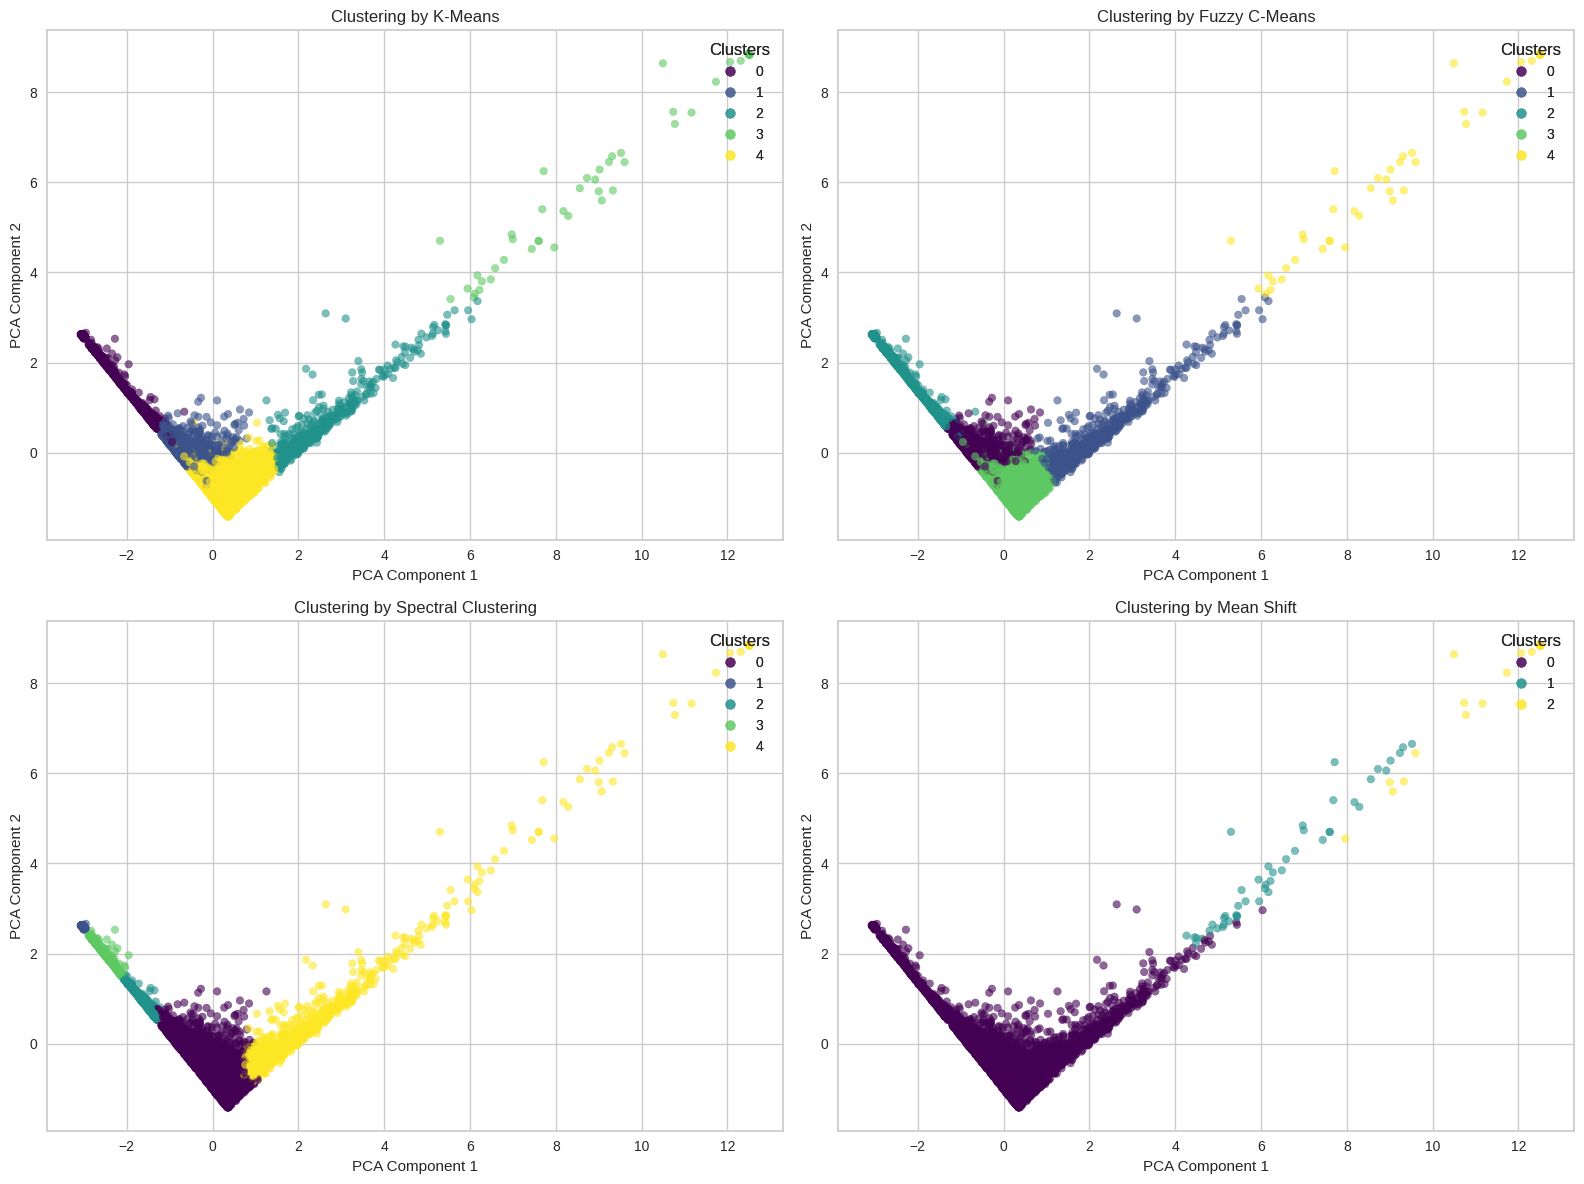

In [ ]:
from sklearn.decomposition import PCA

# Reduce data to 2D for visualisation
pca = PCA(n_components=2)
rfmt_pca = pca.fit_transform(rfmt_scaled)

# Set up layout for 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
algo_columns = ['KMeans_Cluster', 'Fuzzy_Cluster', 'Spectral_Cluster', 'MeanShift_Cluster']
algo_names = ['K-Means', 'Fuzzy C-Means', 'Spectral Clustering', 'Mean Shift']

for i, ax in enumerate(axes.flatten()):
    col = algo_columns[i]
    name = algo_names[i]

    scatter = ax.scatter(rfmt_pca[:, 0], rfmt_pca[:, 1], c=rfmt_cleaned[col], cmap='viridis', alpha=0.6, s=30)
    ax.set_title(f'Clustering by {name}')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

    # Add cluster legend
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
    ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# List of cluster label columns
cluster_columns = ['KMeans_Cluster', 'Fuzzy_Cluster', 'Spectral_Cluster', 'MeanShift_Cluster']

# List to store results
all_cluster_stats = []

# Iterate over each algorithm
for col in cluster_columns:
    if col in rfmt_cleaned.columns:

        # Count customers per cluster
        counts = rfmt_cleaned[col].value_counts().sort_index()

        # Compute percentage
        percentages = (
            rfmt_cleaned[col]
            .value_counts(normalize=True)
            .sort_index() * 100
        )

        # Append each cluster to the list
        for cluster_id in counts.index:
            all_cluster_stats.append({
                "Algorithm": col.replace("_Cluster", ""),
                "Cluster": cluster_id,
                "Count": counts[cluster_id],
                "Percentage (%)": round(percentages[cluster_id], 2)
            })

    else:
        print(f"[!] Column {col} not found")

# Create final summary table
df_cluster_stats = pd.DataFrame(all_cluster_stats)

# Sort for readability
df_cluster_stats = df_cluster_stats.sort_values(
    by=["Algorithm", "Cluster"]
).reset_index(drop=True)

print("CLUSTER SIZE TABLE")
display(df_cluster_stats)

CLUSTER SIZE TABLE


,Algorithm,Cluster,Count,Percentage (%)
0,Fuzzy,0,1306,22.22
1,Fuzzy,1,755,12.84
2,Fuzzy,2,935,15.91
3,Fuzzy,3,2835,48.23
4,Fuzzy,4,47,0.80
5,KMeans,0,981,16.69
6,KMeans,1,1244,21.16
7,KMeans,2,464,7.89
8,KMeans,3,49,0.83
9,KMeans,4,3140,53.42


### RFMT Centroid Profile & Return Rate by K-Means Cluster
Centroid values and return-to-purchase rate for each cluster.

=== RFMT Centroid Profile (K-Means, raw values) ===


,Segment,Recency,Frequency,Monetary,T,N,% Total
Cluster,,,,,,,
0,At-Risk / Dormant,503.0,1.1,323.1,527.3,981,16.7
1,Inactive / Churned,384.0,3.1,942.8,124.4,1244,21.2
2,Potential Loyalists,30.8,24.3,10572.6,32.6,464,7.9
3,Champions / VIPs,26.8,75.8,51439.8,10.5,49,0.8
4,Occasional Buyers,62.6,5.1,1683.3,102.9,3140,53.4


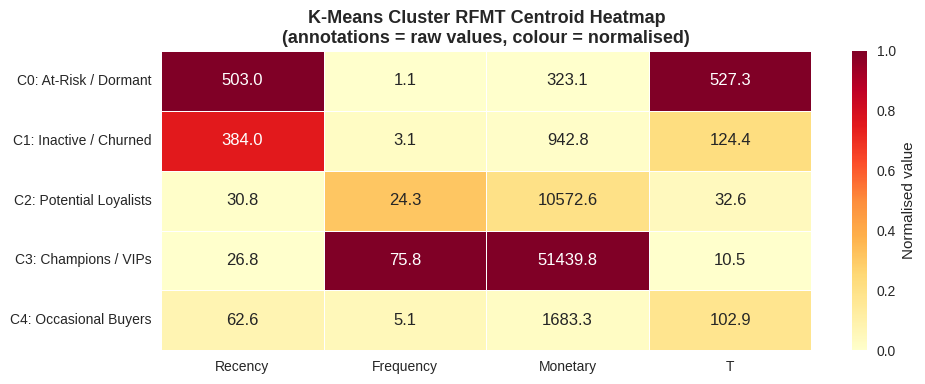

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Compute RFMT centroids for each K-Means cluster ─────────────────────
centroid_df = rfmt_cleaned.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary','T']].mean().round(1)
centroid_df.index.name = 'Cluster'

# ── 2. Add cluster size ─────────────────────────────────────────────────────
centroid_df['N'] = rfmt_cleaned['KMeans_Cluster'].value_counts().sort_index()
centroid_df['% Total'] = (centroid_df['N'] / len(rfmt_cleaned) * 100).round(1)

# ── 3. Assign business labels ───────────────────────────────────────────────
cluster_labels = {
    0: 'At-Risk / Dormant',
    1: 'Inactive / Churned',
    2: 'Potential Loyalists',
    3: 'Champions / VIPs',
    4: 'Occasional Buyers'
}
centroid_df['Segment'] = centroid_df.index.map(cluster_labels)

print("=== RFMT Centroid Profile (K-Means, raw values) ===")
display(centroid_df[['Segment','Recency','Frequency','Monetary','T','N','% Total']])

# ── 4. Normalized heatmap ─────────────────────────────────────────────────────
heat_data = centroid_df[['Recency','Frequency','Monetary','T']].copy()
# Normalise each column to [0,1] for visual comparison
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())
heat_norm.index = [f"C{i}: {cluster_labels[i]}" for i in heat_norm.index]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heat_norm, annot=heat_data.values, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised value'})
ax.set_title('K-Means Cluster RFMT Centroid Heatmap\n(annotations = raw values, colour = normalised)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


###Temporal Split for Prediction Window

In [ ]:
import datetime as dt

# 1. Define the cut-off date
# Use the last date in df_processed to define cutoff_date
max_date = df_processed['InvoiceDate'].max()
cutoff_date = max_date - dt.timedelta(days=30) # 30-day forecast window

# 2. Split data into 2 periods
# Observation period (for feature construction)
obs_df = df_processed[df_processed['InvoiceDate'] < cutoff_date]
# Forecast period (for target construction)
forecast_df = df_processed[df_processed['InvoiceDate'] >= cutoff_date]

print(f"Last date in dataset: {max_date}")
print(f"Cut-off date: {cutoff_date}")
print(f"Observation period rows: {len(obs_df)}")
print(f"Forecast period rows: {len(forecast_df)}")

Last date in dataset: 2011-12-09 12:50:00
Cut-off date: 2011-11-09 12:50:00
Observation period rows: 715163
Forecast period rows: 64262


In [ ]:
# 3. Compute features from the observation period
# Recency: days since the last purchase up to the cutoff date
# Frequency: total invoices in the observation period
# Monetary_Past: total spending in the observation period
analysis_date_obs = cutoff_date

features_df = obs_df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date: (analysis_date_obs - date.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary_Past=('TotalPrice', 'sum')
).reset_index()

# 4. Compute Target: whether customer returned to purchase in the forecast period
# Identify customers who made purchases (with ID in forecast_df) during the forecast period
returned_customers_in_forecast = forecast_df['Customer ID'].unique()

# Build predict_df by combining features_df with the new 'Will_Return' column
predict_df = features_df.copy()
predict_df['Will_Return'] = predict_df['Customer ID'].isin(returned_customers_in_forecast).astype(int)

# Display result
print("Data ready for customer repurchase classification model:")
display(predict_df.head())
print(f"Number of customers available for modelling: {len(predict_df)}")
print(f"Customers who returned (Will_Return = 1): {predict_df['Will_Return'].sum()}")
print(f"Customers who did not return (Will_Return = 0): {len(predict_df) - predict_df['Will_Return'].sum()}")

Data ready for customer repurchase classification model:


,Customer ID,Recency,Frequency,Monetary_Past,Will_Return
0,12346.0,295,12,745.70,0
1,12347.0,9,7,4696.71,1
2,12348.0,44,5,1991.86,0
3,12349.0,377,3,2295.02,1
4,12350.0,279,1,331.34,0


Number of customers available for modelling: 5717
Customers who returned (Will_Return = 1): 1487
Customers who did not return (Will_Return = 0): 4230


### Define Target Variable 'Will_Return' for Classification Model

*   **Observation Period (Features)**: Data from the start up to 30 days before the last date in the dataset.
*   **Forecast Period (Target)**: The last 30 days of the dataset.
*   **Variable `Will_Return`**: Equals 1 if the customer made any transaction during the forecast period, otherwise 0.

=== Will_Return Rate per K-Means Cluster ===


,KMeans_Cluster,Segment,N,Will_Return_1,Return_Rate (%)
0,0,At-Risk/Dormant,981,10,1.0
1,1,Inactive/Churned,1244,0,0.0
2,2,Potential Loyalists,464,345,74.4
3,3,Champions/VIPs,49,45,91.8
4,4,Occasional Buyers,2979,1087,36.5


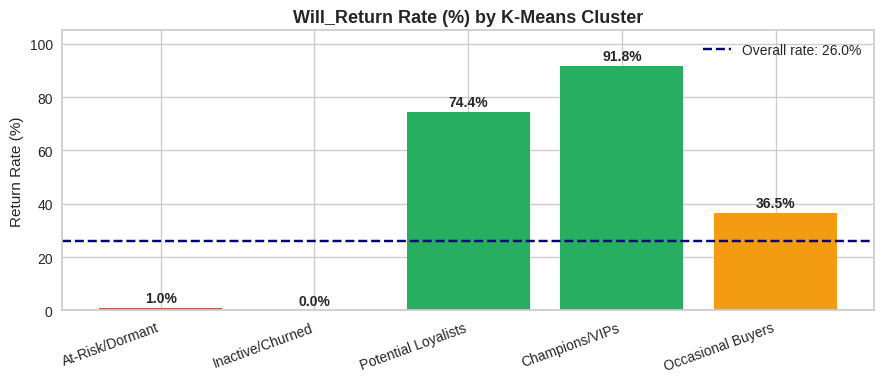

In [ ]:
# Merge cluster labels into predict_df to compute return rate
rr_df = predict_df.merge(
    rfmt_cleaned[['Customer ID','KMeans_Cluster']], on='Customer ID', how='left'
)
rr_df['KMeans_Cluster'] = rr_df['KMeans_Cluster'].fillna(-1).astype(int)

rr_summary = rr_df.groupby('KMeans_Cluster').agg(
    N=('Will_Return','count'),
    Will_Return_1=('Will_Return','sum')
).reset_index()
rr_summary['Return_Rate (%)'] = (rr_summary['Will_Return_1'] / rr_summary['N'] * 100).round(1)
rr_summary['Segment'] = rr_summary['KMeans_Cluster'].map(
    {0:'At-Risk/Dormant', 1:'Inactive/Churned', 2:'Potential Loyalists',
     3:'Champions/VIPs', 4:'Occasional Buyers', -1:'No Cluster'}
)

print("=== Will_Return Rate per K-Means Cluster ===")
display(rr_summary[['KMeans_Cluster','Segment','N','Will_Return_1','Return_Rate (%)']])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if r < 20 else '#f39c12' if r < 50 else '#27ae60'
          for r in rr_summary['Return_Rate (%)'] if rr_summary['KMeans_Cluster'].iloc[rr_summary['Return_Rate (%)'].tolist().index(r)] >= 0]
valid = rr_summary[rr_summary['KMeans_Cluster'] >= 0]
bars = ax.bar(valid['Segment'], valid['Return_Rate (%)'],
              color=['#e74c3c','#e74c3c','#27ae60','#27ae60','#f39c12'])
ax.axhline(rr_df['Will_Return'].mean()*100, color='navy', linestyle='--',
           label=f"Overall rate: {rr_df['Will_Return'].mean()*100:.1f}%")
ax.set_title('Will_Return Rate (%) by K-Means Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Return Rate (%)')
ax.set_ylim(0, 105)
ax.legend()
for bar, val in zip(bars, valid['Return_Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### 💾 Save: train_data.csv

In [ ]:
# ── Export 3/3: train_data.csv ──────────────────────────────────────────
# Merge cluster labels (KMeans, Fuzzy, Spectral) vào predict_df
import os
_save_dir = '/content/drive/MyDrive/GIỮA KỲ_ADM/Data'
os.makedirs(_save_dir, exist_ok=True)

_cluster_cols = ['Customer ID', 'KMeans_Cluster', 'Fuzzy_Cluster', 'Spectral_Cluster']
train_data = predict_df.merge(
    rfmt_cleaned[_cluster_cols],
    on='Customer ID',
    how='left'
)

_path = os.path.join(_save_dir, 'train_data.csv')
train_data.to_csv(_path, index=False)
print(f'✅ train_data.csv  →  {_path}')
print(f'   Shape: {train_data.shape}  |  Columns: {list(train_data.columns)}')
print(f'   Will_Return distribution:\n{train_data["Will_Return"].value_counts().to_string()}')

✅ train_data.csv  →  /content/drive/MyDrive/GIỮA KỲ_ADM/Data/train_data.csv
   Shape: (5717, 8)  |  Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary_Past', 'Will_Return', 'KMeans_Cluster', 'Fuzzy_Cluster', 'Spectral_Cluster']
   Will_Return distribution:
Will_Return
0    4230
1    1487


##3.2 Classification

### 3.2.1 Global Baseline Classification (Without Clustering)

#### Without SMOTE-Tomek

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# Define the classification models (moved from another cell to fix NameError)
classification_models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

all_classification_results_no_clustering = []

print("\nRunning classification on the full dataset (no clustering).")

# Features (X) and Target (y)
X = predict_df[['Recency', 'Frequency', 'Monetary_Past']]
y = predict_df['Will_Return']

# Ensure sufficient data and classes in target for train/test split
if len(y) < 2 or len(X) < 2 or len(y.unique()) < 2 or (len(y.unique()) == 2 and y.value_counts().min() < 2):
    print("Insufficient data or classes to proceed with classification.")
else:
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Iterate over classification models
    for model_name, model in classification_models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] # Probability for class 1

        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Only compute ROC AUC if y_test has 2 classes
        if len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = np.nan # Assign NaN if cannot be computed

        all_classification_results_no_clustering.append({
            'Classification_Algorithm': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc
        })

# Build summary DataFrame from all results
df_classification_no_clustering_eval = pd.DataFrame(all_classification_results_no_clustering)

print("\n--- Classification Performance Evaluation on Full Dataset (No Clustering) ---")
display(df_classification_no_clustering_eval.sort_values(by='F1_Score', ascending=False))


Running classification on the full dataset (no clustering).

--- Classification Performance Evaluation on Full Dataset (No Clustering) ---


,Classification_Algorithm,Accuracy,Precision,Recall,F1_Score,ROC_AUC
3,XGBoost,0.775350,0.624242,0.345638,0.444924,0.744387
1,Random Forest,0.743007,0.508772,0.389262,0.441065,0.724182
2,Gradient Boosting,0.777098,0.644295,0.322148,0.429530,0.750545
0,Logistic Regression,0.781469,0.687500,0.295302,0.413146,0.761991


#### With SMOTE-Tomek

In [ ]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# `classification_models` dictionary is already defined in previous cells

all_classification_results_no_clustering_balanced = []

print("\nRunning classification on the full dataset (no clustering, with class balancing).")

# Features (X) and Target (y)
X = predict_df[['Recency', 'Frequency', 'Monetary_Past']]
y = predict_df['Will_Return']

# Ensure sufficient data and classes in target for train/test split
if len(y) < 2 or len(X) < 2 or len(y.unique()) < 2 or (len(y.unique()) == 2 and y.value_counts().min() < 2):
    print("Insufficient data or classes to proceed with classification and balancing.")
else:
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Determine appropriate k_neighbors for SMOTE based on minority class size
    min_samples_in_minority_class = y_train.value_counts().min()

    if min_samples_in_minority_class > 1:
        smote_k_neighbors = min(5, min_samples_in_minority_class - 1)
        smote_sampler = SMOTE(k_neighbors=smote_k_neighbors, random_state=42)
        smote_tomek_baseline = SMOTETomek(smote=smote_sampler, random_state=42)

        print(f"  Before SMOTE+Tomek: X_train shape {X_train.shape}, y_train counts\n{y_train.value_counts()}")
        X_train_resampled, y_train_resampled = smote_tomek_baseline.fit_resample(X_train, y_train)
        print(f"  After SMOTE+Tomek: X_train_resampled shape {X_train_resampled.shape}, y_train_resampled counts\n{y_train_resampled.value_counts()}")
    else:
        print(f"  Insufficient minority class samples ({min_samples_in_minority_class}) for SMOTE. Using original imbalanced data.")
        X_train_resampled, y_train_resampled = X_train, y_train

    # Iterate over classification models
    for model_name, model in classification_models.items():
        model.fit(X_train_resampled, y_train_resampled) # Train on balanced data
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] # Probability for class 1

        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Only compute ROC AUC if y_test has 2 classes
        if len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = np.nan # Assign NaN if cannot be computed

        all_classification_results_no_clustering_balanced.append({
            'Classification_Algorithm': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc
        })

# Build summary DataFrame from all results
df_classification_no_clustering_balanced_eval = pd.DataFrame(all_classification_results_no_clustering_balanced)

print("\n--- Classification Performance Evaluation on Full Dataset (No Clustering, Balanced) ---")
display(df_classification_no_clustering_balanced_eval.sort_values(by='F1_Score', ascending=False))


Running classification on the full dataset (no clustering, with class balancing).
  Before SMOTE+Tomek: X_train shape (4573, 3), y_train counts
Will_Return
0    3384
1    1189
Name: count, dtype: int64
  After SMOTE+Tomek: X_train_resampled shape (6072, 3), y_train_resampled counts
Will_Return
0    3036
1    3036
Name: count, dtype: int64

--- Classification Performance Evaluation on Full Dataset (No Clustering, Balanced) ---


,Classification_Algorithm,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.669580,0.421260,0.718121,0.531017,0.762106
3,XGBoost,0.671329,0.417373,0.661074,0.511688,0.737618
2,Gradient Boosting,0.667832,0.414226,0.664430,0.510309,0.742686
1,Random Forest,0.678322,0.417453,0.593960,0.490305,0.723053


### 3.2.2 Cluster-Based Classification

####Without SMOTE-Tomek

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# 1. Target variable 'Will_Return' (created in previous step — retained here for safety)
# predict_df['Will_Return'] = (predict_df['Target_Monetary_3m'] > 0).astype(int)

# Define classification models
classification_models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

algo_cluster_columns = {
    'K-Means': 'KMeans_Cluster',
    'Fuzzy C-Means': 'Fuzzy_Cluster',
    'Spectral Clustering': 'Spectral_Cluster',
}

all_classification_results = []

# Iterate over each clustering algorithm
for algo_name, cluster_col_name in algo_cluster_columns.items():
    print(f"\nRunning classification for clustering algorithm: {algo_name}")

    # Ensure the cluster column exists before processing
    if cluster_col_name not in rfmt_cleaned.columns:
        print(f"Column '{cluster_col_name}' not found in data. Skipping this algorithm.")
        continue

    # Merge cluster labels into predict_df
    # Use `rfmt_cleaned` to obtain cluster labels for all customers,
    # then merge with `predict_df` (containing customers with purchase history)
    temp_df = predict_df.merge(rfmt_cleaned[['Customer ID', cluster_col_name]], on='Customer ID', how='left')
    temp_df['Segment'] = temp_df[cluster_col_name].astype(str)

    segments = temp_df['Segment'].unique()

    # Iterate over each segment in the current clustering algorithm
    for segment_label in segments:
        data_segment = temp_df[temp_df['Segment'] == segment_label]

        # Features (X) and Target (y)
        # Use the same features as in the regression step
        X = data_segment[['Recency', 'Frequency', 'Monetary_Past']]
        y = data_segment['Will_Return']

        # Instead of skipping, record result as 0 or NaN
        if len(y.unique()) < 2:
            all_classification_results.append({
                'Clustering_Algorithm': algo_name,
                'Segment_ID': segment_label,
                'Classification_Algorithm': 'N/A (Single Class)',
                'Accuracy': 1.0 if len(y) > 0 else 0, # If 100% single class, accuracy is 1
                'Precision': np.nan,
                'Recall': np.nan,
                'F1_Score': np.nan,
                'ROC_AUC': np.nan
            })
            continue

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        # Iterate over classification models
        for model_name, model in classification_models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1] # Probability for class 1

            # Compute metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            # Only compute ROC AUC if y_test has 2 classes
            if len(np.unique(y_test)) == 2:
                roc_auc = roc_auc_score(y_test, y_prob)
            else:
                roc_auc = np.nan # Assign NaN if cannot be computed

            all_classification_results.append({
                'Clustering_Algorithm': algo_name,
                'Segment_ID': segment_label,
                'Classification_Algorithm': model_name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': roc_auc
            })

# Build summary DataFrame from all results
df_all_classification_eval = pd.DataFrame(all_classification_results)

print("\n--- Detailed Classification Evaluation per Segment for EACH Clustering Algorithm ---")
display(df_all_classification_eval.sort_values(by=['Clustering_Algorithm', 'Segment_ID', 'F1_Score'], ascending=[True, True, False]))

print("\n--- Average Performance Comparison by CLASSIFICATION ALGORITHM (across all segments and clustering algorithms) ---")
overall_avg_classification_perf = df_all_classification_eval.groupby('Classification_Algorithm').agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean',
    'ROC_AUC': 'mean'
})
display(overall_avg_classification_perf.sort_values(by='F1_Score', ascending=False))

print("\n--- Average Performance Comparison by COMBINATION (Clustering × Classification Algorithm) ---")
combined_avg_classification_perf = df_all_classification_eval.groupby(['Clustering_Algorithm', 'Classification_Algorithm']).agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean',
    'ROC_AUC': 'mean'
})
display(combined_avg_classification_perf.sort_values(by=['Clustering_Algorithm', 'F1_Score'], ascending=[True, False]))


Running classification for clustering algorithm: K-Means

Running classification for clustering algorithm: Fuzzy C-Means

Running classification for clustering algorithm: Spectral Clustering

--- Detailed Classification Evaluation per Segment for EACH Clustering Algorithm ---


,Clustering_Algorithm,Segment_ID,Classification_Algorithm,Accuracy,Precision,Recall,F1_Score,ROC_AUC
17,Fuzzy C-Means,0,N/A (Single Class),1.000000,NaN,NaN,NaN,NaN
26,Fuzzy C-Means,1,Logistic Regression,0.622517,0.669118,0.883495,0.761506,0.631472
28,Fuzzy C-Means,1,Gradient Boosting,0.649007,0.711864,0.815534,0.760181,0.691242
29,Fuzzy C-Means,1,XGBoost,0.649007,0.711864,0.815534,0.760181,0.637338
27,Fuzzy C-Means,1,Random Forest,0.655629,0.733945,0.776699,0.754717,0.618528
22,Fuzzy C-Means,2,Logistic Regression,0.989305,0.000000,0.000000,0.000000,0.218919
23,Fuzzy C-Means,2,Random Forest,0.989305,0.000000,0.000000,0.000000,0.705405
24,Fuzzy C-Means,2,Gradient Boosting,0.989305,0.000000,0.000000,0.000000,0.537838
25,Fuzzy C-Means,2,XGBoost,0.989305,0.000000,0.000000,0.000000,0.709459
19,Fuzzy C-Means,3,Random Forest,0.678505,0.554545,0.331522,0.414966,0.604492



--- Average Performance Comparison by CLASSIFICATION ALGORITHM (across all segments and clustering algorithms) ---


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Classification_Algorithm,,,,,
Random Forest,0.791313,0.553378,0.538044,0.538799,0.700104
XGBoost,0.797183,0.582982,0.510836,0.520988,0.711736
Gradient Boosting,0.811456,0.635381,0.496432,0.518825,0.737610
Logistic Regression,0.821701,0.578719,0.523910,0.504241,0.619496
N/A (Single Class),1.000000,NaN,NaN,NaN,NaN



--- Average Performance Comparison by COMBINATION (Clustering × Classification Algorithm) ---


Accuracy  Precision    Recall  \
Clustering_Algorithm Classification_Algorithm                                  
Fuzzy C-Means        Random Forest             0.805860   0.547123  0.527055   
                     Logistic Regression       0.831927   0.642279  0.519787   
                     XGBoost                   0.809812   0.572084  0.516383   
                     Gradient Boosting         0.813083   0.623421  0.484530   
                     N/A (Single Class)        1.000000        NaN       NaN   
K-Means              Random Forest             0.815321   0.556989  0.564817   
                     Gradient Boosting         0.849947   0.629180  0.535364   
                     XGBoost                   0.818163   0.584234  0.537167   
                     Logistic Regression       0.857194   0.637456  0.539989   
                     N/A (Single Class)        1.000000        NaN       NaN   
Spectral Clustering  Random Forest             0.714204   0.558668  0.506478   
                     XGBoost                   0.729968   0.602273  0.447081   
                     Gradient Boosting         0.731221   0.671703  0.442376   
                     Logistic Regression       0.730262   0.334123  0.500000   
                     N/A (Single Class)        1.000000        NaN       NaN   

                                               F1_Score   ROC_AUC  
Clustering_Algorithm Classification_Algorithm                      
Fuzzy C-Means        Random Forest             0.529263  0.732106  
                     Logistic Regression       0.520734  0.611400  
                     XGBoost                   0.518157  0.691302  
                     Gradient Boosting         0.515298  0.705948  
                     N/A (Single Class)             NaN       NaN  
K-Means              Random Forest             0.559100  0.677339  
                     Gradient Boosting         0.554806  0.779961  
                     XGBoost                   0.544838  0.748745  
                     Logistic Regression       0.539584  0.653061  
                     N/A (Single Class)             NaN       NaN  
Spectral Clustering  Random Forest             0.517270  0.681628  
                     XGBoost                   0.478947  0.678586  
                     Gradient Boosting         0.453918  0.716229  
                     Logistic Regression       0.400568  0.568557  
                     N/A (Single Class)             NaN       NaN

In [ ]:
!pip install imblearn

####With SMOTE-Tomek

In [ ]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE # Import SMOTE

# Existing classification models dictionary
classification_models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

algo_cluster_columns = {
    'K-Means': 'KMeans_Cluster',
    'Fuzzy C-Means': 'Fuzzy_Cluster',
    'Spectral Clustering': 'Spectral_Cluster',
}

all_classification_results_balanced = []

# Initialize SMOTETomek (this will be re-initialized per segment if k_neighbors needs adjustment)
# smote_tomek = SMOTETomek(random_state=42) # Remove global initialization

# Iterate over each clustering algorithm
for algo_name, cluster_col_name in algo_cluster_columns.items():
    print(f"\nRunning classification for clustering algorithm: {algo_name} (With class balancing)")

    # Ensure the cluster column exists before processing
    if cluster_col_name not in rfmt_cleaned.columns:
        print(f"Column '{cluster_col_name}' not found in data. Skipping this algorithm.")
        continue

    # Merge cluster labels into predict_df
    # Use `rfmt_cleaned` to obtain cluster labels for all customers,
    # then merge with `predict_df` (containing customers with purchase history)
    temp_df = predict_df.merge(rfmt_cleaned[['Customer ID', cluster_col_name]], on='Customer ID', how='left')
    temp_df['Segment'] = temp_df[cluster_col_name].astype(str)

    segments = temp_df['Segment'].unique()

    # Iterate over each segment in the current clustering algorithm
    for segment_label in segments:
        data_segment = temp_df[temp_df['Segment'] == segment_label]

        # Features (X) and Target (y)
        # Use the same features as in the regression step
        X = data_segment[['Recency', 'Frequency', 'Monetary_Past']]
        y = data_segment['Will_Return']

       # Instead of skipping, record result as 0 or NaN
        if len(y.unique()) < 2:
            all_classification_results.append({
                'Clustering_Algorithm': algo_name,
                'Segment_ID': segment_label,
                'Classification_Algorithm': 'N/A (Single Class)',
                'Accuracy': 1.0 if len(y) > 0 else 0, # If 100% single class, accuracy is 1
                'Precision': np.nan,
                'Recall': np.nan,
                'F1_Score': np.nan,
                'ROC_AUC': np.nan
            })
            continue

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        # Determine appropriate k_neighbors for SMOTE based on minority class size
        min_samples_in_minority_class = y_train.value_counts().min()

        # SMOTE requires k_neighbors to be at least 1, and less than the number of minority samples.
        if min_samples_in_minority_class > 1:
            # Use min(5, min_samples_in_minority_class - 1) to ensure k_neighbors is valid.
            # Default k_neighbors for SMOTE is 5.
            smote_k_neighbors = min(5, min_samples_in_minority_class - 1)

            # Initialize SMOTE and SMOTETomek for the current segment
            smote_sampler = SMOTE(k_neighbors=smote_k_neighbors, random_state=42)
            smote_tomek_segment = SMOTETomek(smote=smote_sampler, random_state=42)

            # Apply SMOTE+Tomek to balance the training set
            print(f"  Segment {segment_label} - Before SMOTE+Tomek: X_train shape {X_train.shape}, y_train counts\n{y_train.value_counts()}")
            X_train_resampled, y_train_resampled = smote_tomek_segment.fit_resample(X_train, y_train)
            print(f"  Segment {segment_label} - After SMOTE+Tomek: X_train_resampled shape {X_train_resampled.shape}, y_train_resampled counts\n{y_train_resampled.value_counts()}")

        else:
            # If minority class has 1 or 0 samples, SMOTE cannot be applied.
            # The `if` condition above should catch `min_samples_in_minority_class < 2`, but this is a fallback.
            print(f"  Segment {segment_label} - Insufficient minority class samples ({min_samples_in_minority_class}) for SMOTE. Using original imbalanced data.")
            X_train_resampled, y_train_resampled = X_train, y_train # Use original data if balancing is not possible

        # Iterate over classification models
        for model_name, model in classification_models.items():
            model.fit(X_train_resampled, y_train_resampled) # Train on balanced data
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1] # Probability for class 1

            # Compute metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            # Only compute ROC AUC if y_test has 2 classes
            if len(np.unique(y_test)) == 2:
                roc_auc = roc_auc_score(y_test, y_prob)
            else:
                roc_auc = np.nan # Assign NaN if cannot be computed

            all_classification_results_balanced.append({
                'Clustering_Algorithm': algo_name,
                'Segment_ID': segment_label,
                'Classification_Algorithm': model_name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': roc_auc
            })

# Build summary DataFrame from all results
df_all_classification_eval_balanced = pd.DataFrame(all_classification_results_balanced)

print("\n--- Detailed Classification Evaluation per Segment (BALANCED data) ---")
display(df_all_classification_eval_balanced.sort_values(by=['Clustering_Algorithm', 'Segment_ID', 'F1_Score'], ascending=[True, True, False]))

print("\n--- Average Performance by CLASSIFICATION ALGORITHM (all segments and clustering algorithms, BALANCED data) ---")
overall_avg_classification_perf_balanced = df_all_classification_eval_balanced.groupby('Classification_Algorithm').agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean',
    'ROC_AUC': 'mean'
})
display(overall_avg_classification_perf_balanced.sort_values(by='F1_Score', ascending=False))

print("\n--- Average Performance by COMBINATION (Clustering × Classification, BALANCED data) ---")
combined_avg_classification_perf_balanced = df_all_classification_eval_balanced.groupby(['Clustering_Algorithm', 'Classification_Algorithm']).agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1_Score': 'mean',
    'ROC_AUC': 'mean'
})
display(combined_avg_classification_perf_balanced.sort_values(by=['Clustering_Algorithm', 'F1_Score'], ascending=[True, False]))


Running classification for clustering algorithm: K-Means (With class balancing)
  Segment 4 - Before SMOTE+Tomek: X_train shape (2383, 3), y_train counts
Will_Return
0    1513
1     870
Name: count, dtype: int64
  Segment 4 - After SMOTE+Tomek: X_train_resampled shape (2548, 3), y_train_resampled counts
Will_Return
1    1274
0    1274
Name: count, dtype: int64
  Segment 0 - Before SMOTE+Tomek: X_train shape (784, 3), y_train counts
Will_Return
0    776
1      8
Name: count, dtype: int64
  Segment 0 - After SMOTE+Tomek: X_train_resampled shape (1494, 3), y_train_resampled counts
Will_Return
0    747
1    747
Name: count, dtype: int64
  Segment 2 - Before SMOTE+Tomek: X_train shape (371, 3), y_train counts
Will_Return
1    276
0     95
Name: count, dtype: int64
  Segment 2 - After SMOTE+Tomek: X_train_resampled shape (470, 3), y_train_resampled counts
Will_Return
1    235
0    235
Name: count, dtype: int64
  Segment 3 - Before SMOTE+Tomek: X_train shape (39, 3), y_train counts
Will_Retu

,Clustering_Algorithm,Segment_ID,Classification_Algorithm,Accuracy,Precision,Recall,F1_Score,ROC_AUC
26,Fuzzy C-Means,1,Gradient Boosting,0.615894,0.747253,0.660194,0.701031,0.660902
27,Fuzzy C-Means,1,XGBoost,0.602649,0.731183,0.660194,0.693878,0.631472
24,Fuzzy C-Means,1,Logistic Regression,0.629139,0.805195,0.601942,0.688889,0.655744
25,Fuzzy C-Means,1,Random Forest,0.596026,0.744186,0.621359,0.677249,0.610538
20,Fuzzy C-Means,2,Logistic Regression,0.641711,0.028986,1.000000,0.056338,0.802703
21,Fuzzy C-Means,2,Random Forest,0.941176,0.000000,0.000000,0.000000,0.505405
22,Fuzzy C-Means,2,Gradient Boosting,0.919786,0.000000,0.000000,0.000000,0.337838
23,Fuzzy C-Means,2,XGBoost,0.925134,0.000000,0.000000,0.000000,0.543243
19,Fuzzy C-Means,3,XGBoost,0.642991,0.482234,0.516304,0.498688,0.634894
18,Fuzzy C-Means,3,Gradient Boosting,0.622430,0.455882,0.505435,0.479381,0.633113



--- Average Performance by CLASSIFICATION ALGORITHM (all segments and clustering algorithms, BALANCED data) ---


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Classification_Algorithm,,,,,
XGBoost,0.758004,0.568972,0.662199,0.570584,0.749855
Gradient Boosting,0.727372,0.564593,0.635925,0.550754,0.725992
Logistic Regression,0.680046,0.554735,0.742923,0.547587,0.735670
Random Forest,0.729070,0.541323,0.568548,0.533959,0.709696



--- Average Performance by COMBINATION (Clustering × Classification, BALANCED data) ---


Accuracy  Precision    Recall  \
Clustering_Algorithm Classification_Algorithm                                  
Fuzzy C-Means        XGBoost                   0.792693   0.553354  0.544125   
                     Gradient Boosting         0.764528   0.550784  0.513629   
                     Logistic Regression       0.695049   0.565688  0.724610   
                     Random Forest             0.766310   0.525332  0.514035   
K-Means              XGBoost                   0.769249   0.596599  0.789326   
                     Logistic Regression       0.708775   0.585307  0.791146   
                     Gradient Boosting         0.728571   0.583601  0.763853   
                     Random Forest             0.722938   0.556120  0.628317   
Spectral Clustering  XGBoost                   0.666132   0.544956  0.644094   
                     Gradient Boosting         0.650662   0.554195  0.624659   
                     Logistic Regression       0.592581   0.471687  0.683101   
                     Random Forest             0.666855   0.543713  0.558033   

                                               F1_Score   ROC_AUC  
Clustering_Algorithm Classification_Algorithm                      
Fuzzy C-Means        XGBoost                   0.548141  0.702402  
                     Gradient Boosting         0.530397  0.657963  
                     Logistic Regression       0.526058  0.761599  
                     Random Forest             0.517575  0.675510  
K-Means              XGBoost                   0.590132  0.824719  
                     Logistic Regression       0.570977  0.776311  
                     Gradient Boosting         0.564677  0.804409  
                     Random Forest             0.545399  0.752733  
Spectral Clustering  XGBoost                   0.576374  0.695031  
                     Gradient Boosting         0.563622  0.705215  
                     Logistic Regression       0.543868  0.602529  
                     Random Forest             0.543848  0.691994

## 3.3 Comparison: Global Baseline vs Cluster-Based Classification

### Classification Performance Comparison (With and Without Clustering / Balancing)

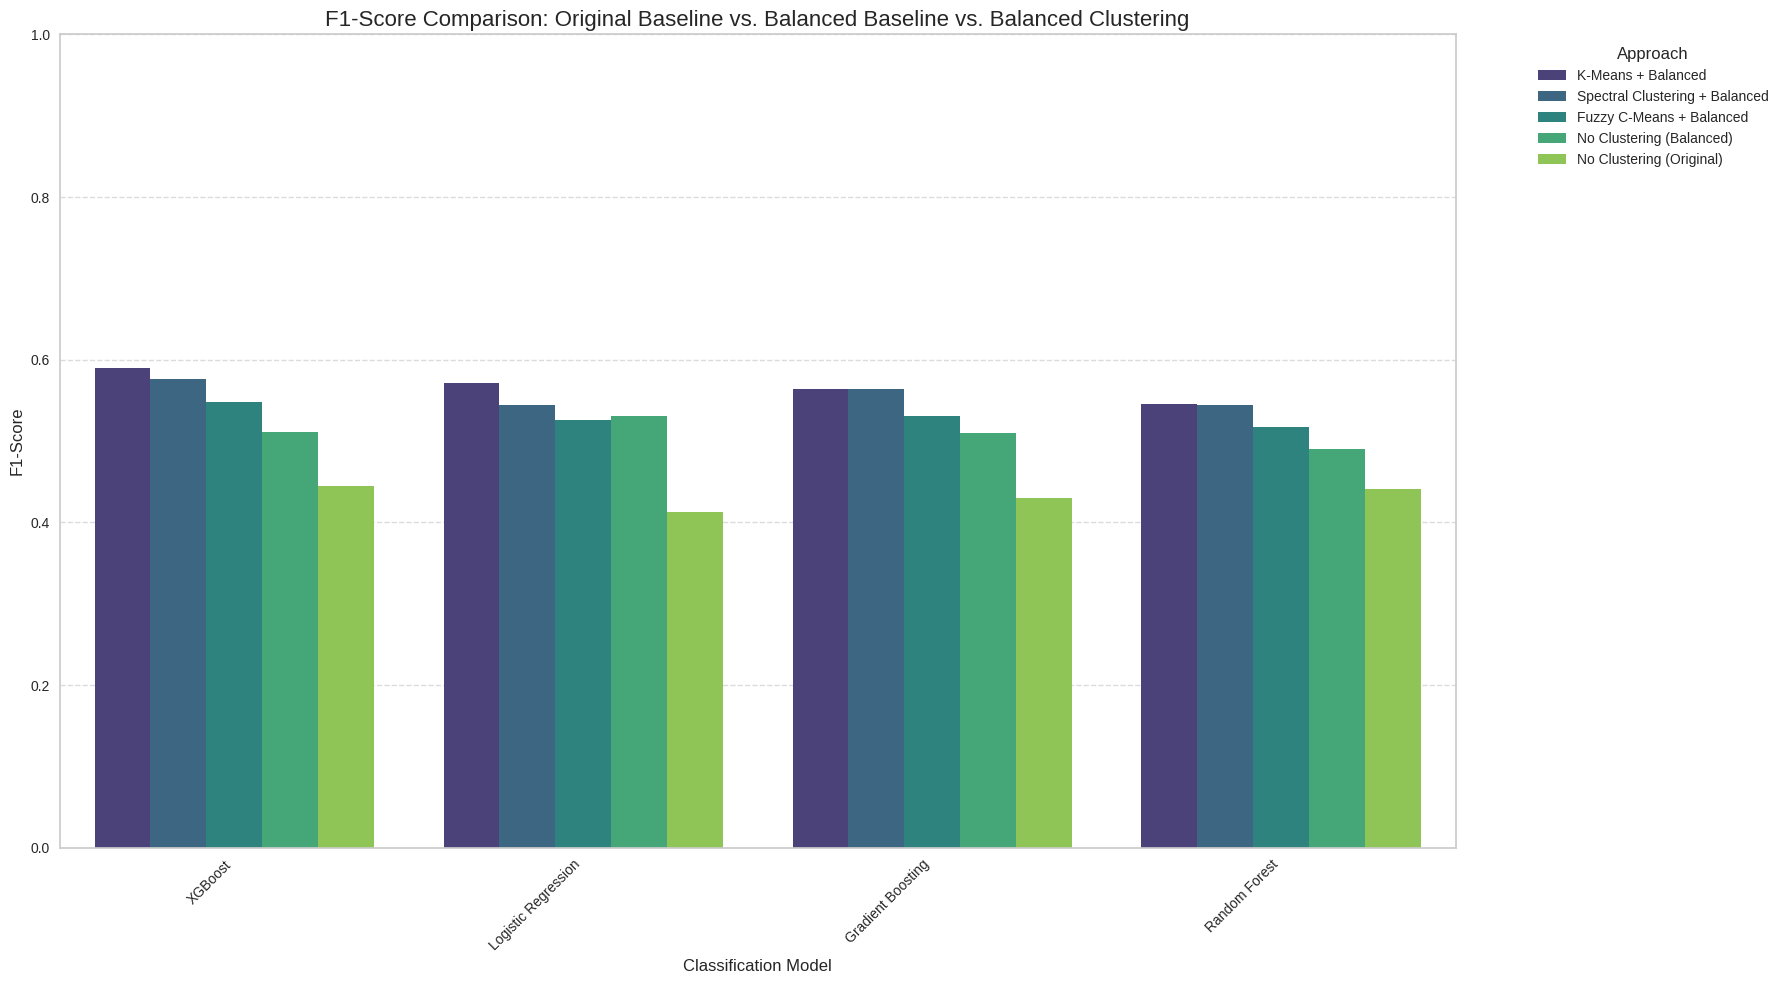

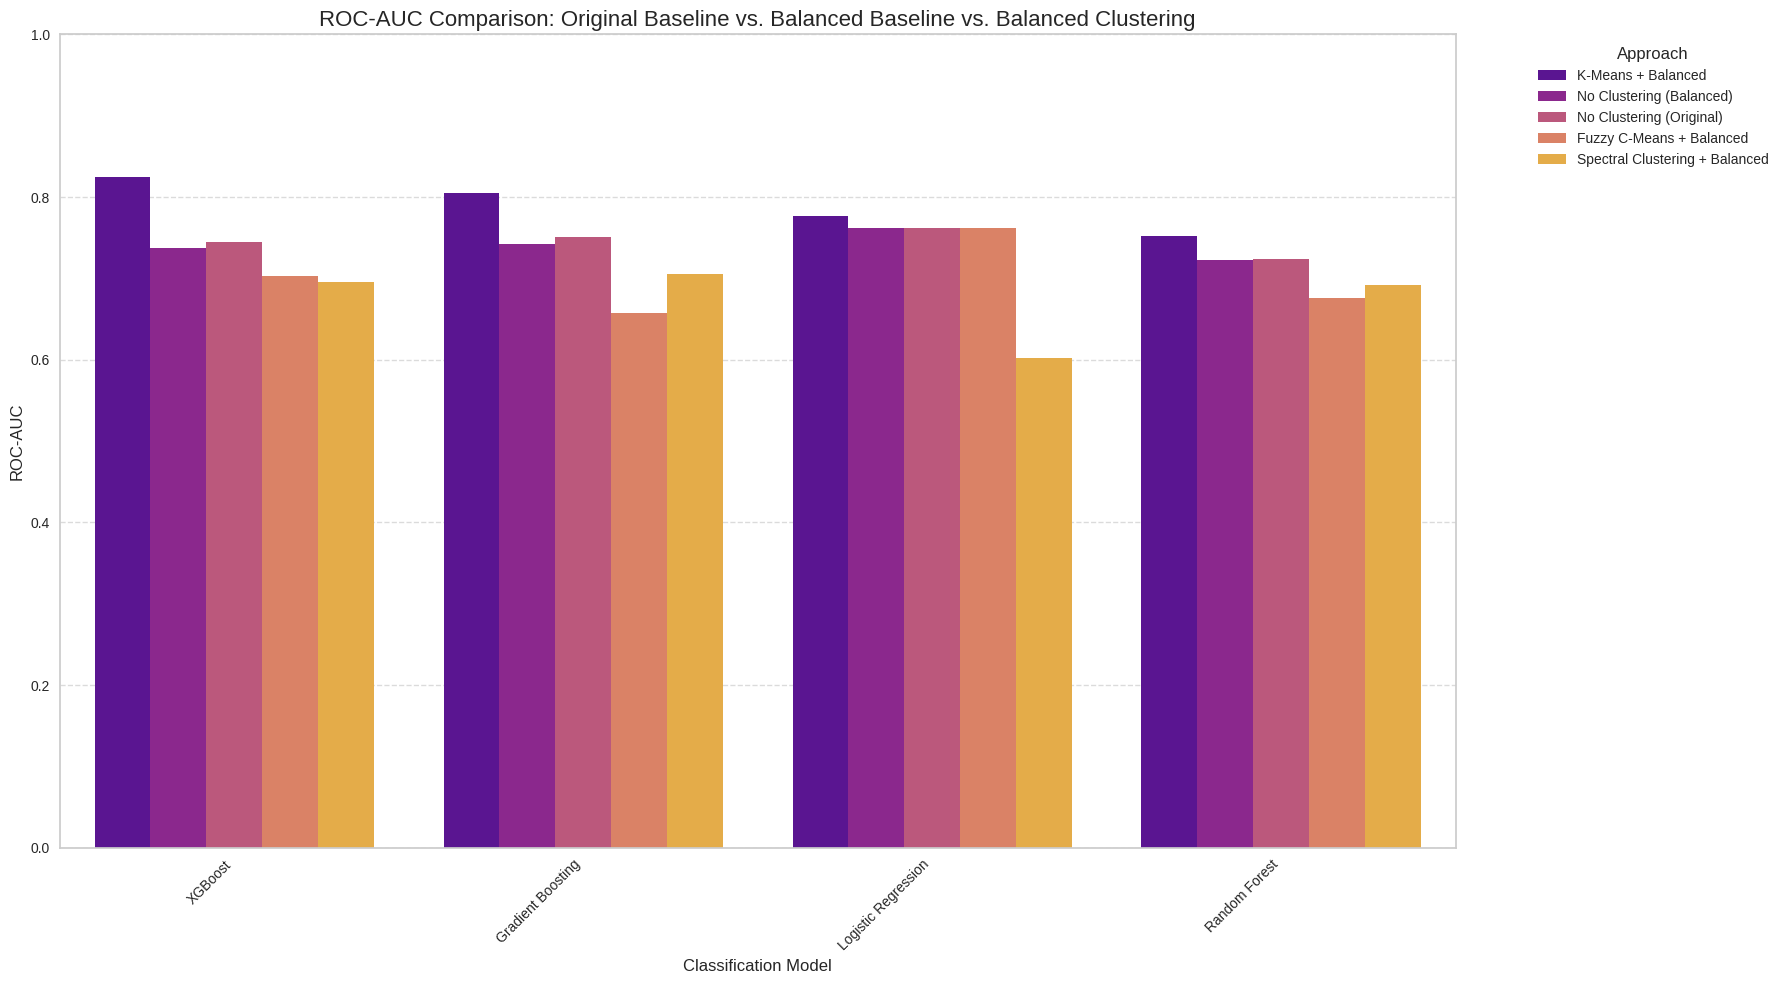

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Retrieve data from no-clustering classification (ORIGINAL BASELINE)
df_no_clustering = df_classification_no_clustering_eval.copy()
df_no_clustering['Approach'] = 'No Clustering (Original)'
df_no_clustering = df_no_clustering.rename(columns={'Classification_Algorithm': 'Model'})

# 2. Retrieve data from no-clustering classification (BALANCED)
df_no_clustering_balanced = df_classification_no_clustering_balanced_eval.copy()
df_no_clustering_balanced['Approach'] = 'No Clustering (Balanced)'
df_no_clustering_balanced = df_no_clustering_balanced.rename(columns={'Classification_Algorithm': 'Model'})

# 3. Retrieve data from cluster-based classification (BALANCED)
df_with_clustering = combined_avg_classification_perf_balanced.reset_index()
df_with_clustering['Approach'] = df_with_clustering['Clustering_Algorithm'] + ' + Balanced'
df_with_clustering = df_with_clustering.rename(columns={'Classification_Algorithm': 'Model'})

# Combine all DataFrames
# Select required columns and ensure format compatibility
comparison_df_no_cluster_orig = df_no_clustering[['Model', 'Approach', 'F1_Score', 'ROC_AUC']]
comparison_df_no_cluster_balanced = df_no_clustering_balanced[['Model', 'Approach', 'F1_Score', 'ROC_AUC']]
comparison_df_with_cluster_balanced = df_with_clustering[['Model', 'Approach', 'F1_Score', 'ROC_AUC']]

# Concatenate DataFrames
final_comparison_df_all = pd.concat([
    comparison_df_no_cluster_orig,
    comparison_df_no_cluster_balanced,
    comparison_df_with_cluster_balanced
], ignore_index=True)

# --- Visualise F1-Score ---
plt.figure(figsize=(18, 10)) # Enlarged for readability
sns.barplot(data=final_comparison_df_all.sort_values(by='F1_Score', ascending=False),
            x='Model',
            y='F1_Score',
            hue='Approach',
            palette='viridis')
plt.title('F1-Score Comparison: Original Baseline vs. Balanced Baseline vs. Balanced Clustering', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Classification Model', fontsize=12)
plt.ylim(0, 1) # F1-Score is between 0 and 1
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Approach', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Visualise ROC-AUC ---
plt.figure(figsize=(18, 10)) # Enlarged for readability
sns.barplot(data=final_comparison_df_all.sort_values(by='ROC_AUC', ascending=False),
            x='Model',
            y='ROC_AUC',
            hue='Approach',
            palette='plasma')
plt.title('ROC-AUC Comparison: Original Baseline vs. Balanced Baseline vs. Balanced Clustering', fontsize=16)
plt.ylabel('ROC-AUC', fontsize=12)
plt.xlabel('Classification Model', fontsize=12)
plt.ylim(0, 1) # ROC-AUC is between 0 and 1
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Approach', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary: Global Baseline vs Cluster-Based Classification
Direct comparison of F1-Score and ROC-AUC between the global model (no clustering) and cluster-based models.

In [ ]:
# ── Head-to-head summary: Global vs Local (SMOTE) ──────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Global baselines (from cells 63, 65) ---
global_orig = df_classification_no_clustering_eval.copy()
global_orig['Pipeline'] = 'Global (no SMOTE)'

global_smote = df_classification_no_clustering_balanced_eval.copy()
global_smote['Pipeline'] = 'Global + SMOTE'

# --- Best cluster-based: compute avg per (Clustering × Classifier) with SMOTE ---
clust_smote = combined_avg_classification_perf_balanced.reset_index()
clust_smote.columns = ['Clustering_Algorithm','Classification_Algorithm',
                       'Accuracy','Precision','Recall','F1_Score','ROC_AUC']
clust_smote['Pipeline'] = clust_smote['Clustering_Algorithm'] + ' + SMOTE'
clust_smote = clust_smote.rename(columns={'Classification_Algorithm':'Classification_Algorithm'})

# Concatenate and display summary table
summary_rows = []
for _, row in global_orig.iterrows():
    summary_rows.append({'Pipeline': row['Pipeline'],
                         'Classifier': row['Classification_Algorithm'],
                         'F1': row['F1_Score'], 'ROC_AUC': row['ROC_AUC'],
                         'Recall': row['Recall']})
for _, row in global_smote.iterrows():
    summary_rows.append({'Pipeline': row['Pipeline'],
                         'Classifier': row['Classification_Algorithm'],
                         'F1': row['F1_Score'], 'ROC_AUC': row['ROC_AUC'],
                         'Recall': row['Recall']})
for _, row in clust_smote.iterrows():
    summary_rows.append({'Pipeline': row['Pipeline'],
                         'Classifier': row['Classification_Algorithm'],
                         'F1': row['F1_Score'], 'ROC_AUC': row['ROC_AUC'],
                         'Recall': row['Recall']})

df_head2head = pd.DataFrame(summary_rows)

print("=== HEAD-TO-HEAD: Global vs Cluster-Based (F1-Score) ===")
pivot = df_head2head.pivot_table(index='Pipeline', columns='Classifier',
                                  values='F1', aggfunc='mean').round(4)
display(pivot.sort_values(by='XGBoost', ascending=False))

# ── Compute ΔF1 vs Global + SMOTE XGBoost ──────────────────────────────────
baseline_f1 = global_smote.loc[global_smote['Classification_Algorithm']=='XGBoost','F1_Score'].values[0]
print(f"\nBaseline F1 (Global XGBoost + SMOTE): {baseline_f1:.4f}")
print("\nDelta F1 (Cluster-based + SMOTE  vs  Global + SMOTE XGBoost):")
delta_df = clust_smote[['Pipeline','Classification_Algorithm','F1_Score']].copy()
delta_df['ΔF1'] = (delta_df['F1_Score'] - baseline_f1).round(4)
delta_df['ΔF1 (%)'] = ((delta_df['F1_Score'] - baseline_f1) / baseline_f1 * 100).round(1)
display(delta_df.sort_values('F1_Score', ascending=False).head(10))


=== HEAD-TO-HEAD: Global vs Cluster-Based (F1-Score) ===


Classifier,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Pipeline,,,,
K-Means + SMOTE,0.5647,0.5710,0.5454,0.5901
Spectral Clustering + SMOTE,0.5636,0.5439,0.5438,0.5764
Fuzzy C-Means + SMOTE,0.5304,0.5261,0.5176,0.5481
Global + SMOTE,0.5103,0.5310,0.4903,0.5117
Global (no SMOTE),0.4295,0.4131,0.4411,0.4449



Baseline F1 (Global XGBoost + SMOTE): 0.5117

Delta F1 (Cluster-based + SMOTE  vs  Global + SMOTE XGBoost):


,Pipeline,Classification_Algorithm,F1_Score,ΔF1,ΔF1 (%)
7,K-Means + SMOTE,XGBoost,0.590132,0.0784,15.3
11,Spectral Clustering + SMOTE,XGBoost,0.576374,0.0647,12.6
5,K-Means + SMOTE,Logistic Regression,0.570977,0.0593,11.6
4,K-Means + SMOTE,Gradient Boosting,0.564677,0.0530,10.4
8,Spectral Clustering + SMOTE,Gradient Boosting,0.563622,0.0519,10.1
3,Fuzzy C-Means + SMOTE,XGBoost,0.548141,0.0365,7.1
6,K-Means + SMOTE,Random Forest,0.545399,0.0337,6.6
9,Spectral Clustering + SMOTE,Logistic Regression,0.543868,0.0322,6.3
10,Spectral Clustering + SMOTE,Random Forest,0.543848,0.0322,6.3
0,Fuzzy C-Means + SMOTE,Gradient Boosting,0.530397,0.0187,3.7


###Confusion Matrix — Best Pipeline (K-Means × XGBoost + SMOTE+Tomek)

=== Confusion Matrix: K-Means × XGBoost + SMOTE+Tomek (Aggregated Across All Segments) ===


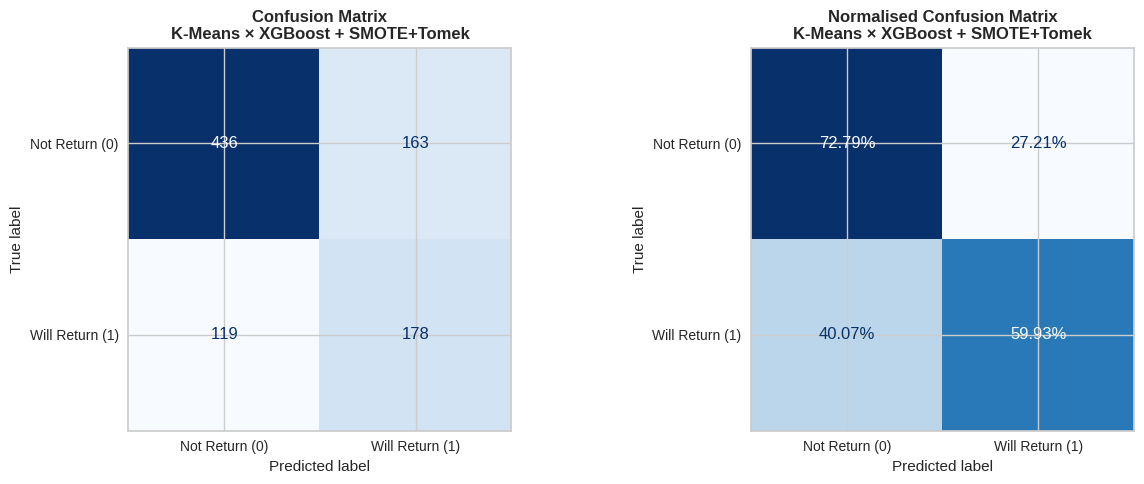


=== Classification Report ===
                 precision    recall  f1-score   support

 Not Return (0)       0.79      0.73      0.76       599
Will Return (1)       0.52      0.60      0.56       297

       accuracy                           0.69       896
      macro avg       0.65      0.66      0.66       896
   weighted avg       0.70      0.69      0.69       896



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

print("=== Confusion Matrix: K-Means × XGBoost + SMOTE+Tomek (Aggregated Across All Segments) ===")


all_y_test, all_y_pred = [], []

# Retrieve K-Means cluster labels
temp_df = predict_df.merge(rfmt_cleaned[['Customer ID','KMeans_Cluster']], on='Customer ID', how='left')
temp_df['Segment'] = temp_df['KMeans_Cluster'].astype(str)

for seg in temp_df['Segment'].dropna().unique():
    data_seg = temp_df[temp_df['Segment'] == seg]
    X = data_seg[['Recency','Frequency','Monetary_Past']]
    y = data_seg['Will_Return']
    if len(y.unique()) < 2:
        continue
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    k_nb = min(5, y_train.value_counts().min() - 1)
    if k_nb < 1:
        X_res, y_res = X_train, y_train
    else:
        st = SMOTETomek(smote=SMOTE(k_neighbors=k_nb, random_state=42), random_state=42)
        X_res, y_res = st.fit_resample(X_train, y_train)
    model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
    model_xgb.fit(X_res, y_res)
    y_pred = model_xgb.predict(X_test)
    all_y_test.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

cm = confusion_matrix(all_y_test, all_y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Return (0)','Will Return (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nK-Means × XGBoost + SMOTE+Tomek', fontsize=12, fontweight='bold')

# Normalised version
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Not Return (0)','Will Return (1)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Normalised Confusion Matrix\nK-Means × XGBoost + SMOTE+Tomek', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(all_y_test, all_y_pred, target_names=['Not Return (0)','Will Return (1)']))


## 3.4 Cluster Profiling — RFMT Behavioral Deep-Dive

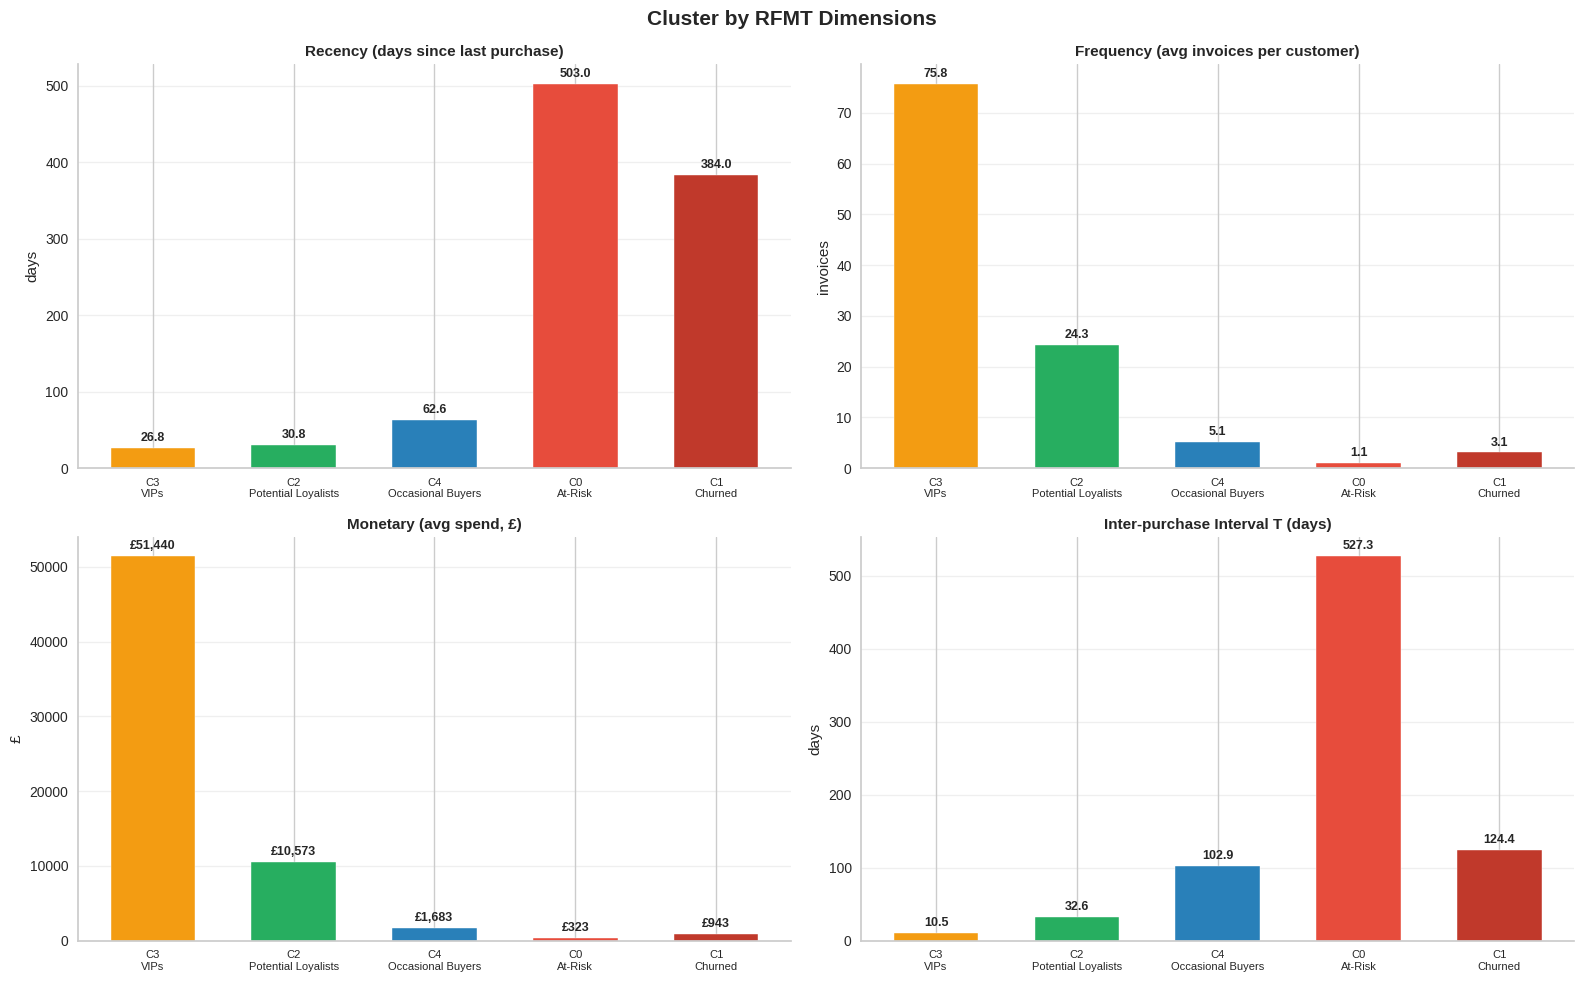

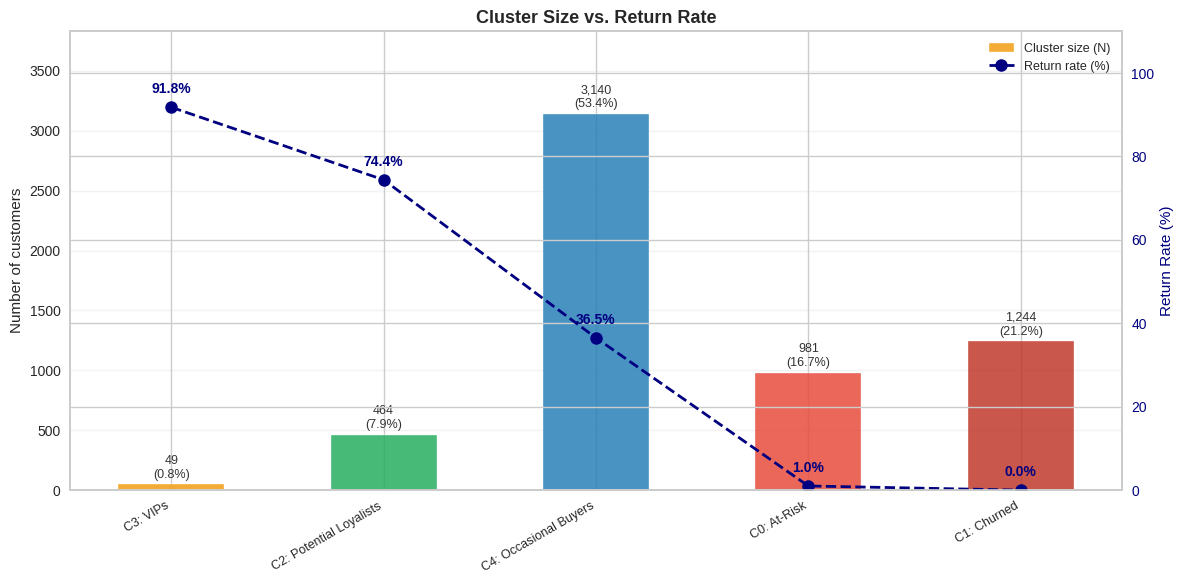

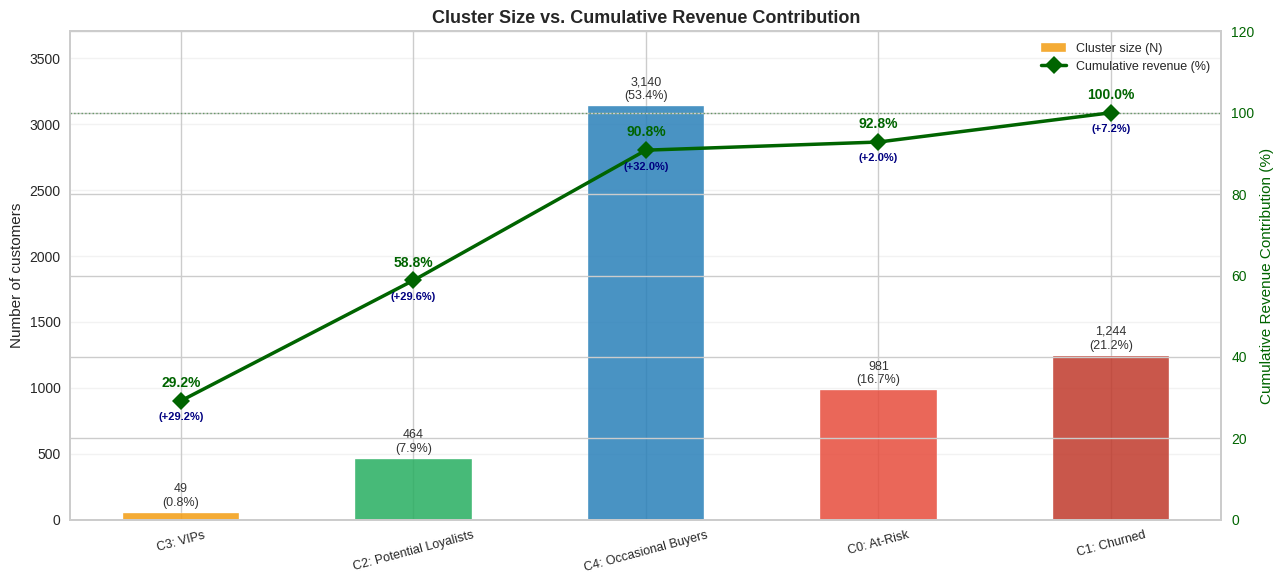

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.3 CLUSTER PROFILING — RFMT Behavioral Deep-Dive
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from math import pi

# ── 0. Assemble data ────────────────────────────────────────────────────────
centroid = rfmt_cleaned.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary','T']].mean().round(1)
sizes    = rfmt_cleaned['KMeans_Cluster'].value_counts().sort_index()
centroid['N']        = sizes
centroid['PctTotal'] = (sizes / len(rfmt_cleaned) * 100).round(1)
rr = (predict_df
      .merge(rfmt_cleaned[['Customer ID','KMeans_Cluster']], on='Customer ID', how='left')
      .groupby('KMeans_Cluster')['Will_Return'].mean().mul(100).round(1))
centroid['ReturnRate'] = rr

COLORS = {0:'#E74C3C', 1:'#C0392B', 2:'#27AE60', 3:'#F39C12', 4:'#2980B9'}
LABELS = {0:'At-Risk', 1:'Churned',
          2:'Potential Loyalists', 3:'VIPs', 4:'Occasional Buyers'}
ORDER  = [3, 2, 4, 0, 1]   # high → low return rate


# ══════════════════════════════════════════════════════════════════════════════
# CHART 1 — Per-cluster RFMT bar charts (4 metrics × 5 clusters)
# ══════════════════════════════════════════════════════════════════════════════
metrics = ['Recency','Frequency','Monetary','T']
units   = ['days', 'invoices', '£', 'days']
titles  = ['Recency (days since last purchase)',
           'Frequency (avg invoices per customer)',
           'Monetary (avg spend, £)',
           'Inter-purchase Interval T (days)']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Cluster by RFMT Dimensions', fontsize=15, fontweight='bold')

for ax, metric, title, unit in zip(axes.flatten(), metrics, titles, units):
    vals   = [centroid.loc[c, metric] for c in ORDER]
    colors = [COLORS[c] for c in ORDER]
    names  = [f"C{c}\n{LABELS[c]}" for c in ORDER]
    bars   = ax.bar(names, vals, color=colors, edgecolor='white', width=0.6)
    for bar, val in zip(bars, vals):
        fmt = f'£{val:,.0f}' if metric == 'Monetary' else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(unit)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# CHART 2 — Cluster size + return rate dual-axis
# ══════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(12, 6))
names  = [f"C{c}: {LABELS[c]}" for c in ORDER]
sizes_ = [int(centroid.loc[c, 'N'])  for c in ORDER]
rrates = [centroid.loc[c, 'ReturnRate'] for c in ORDER]
colors = [COLORS[c] for c in ORDER]

x = np.arange(len(ORDER))
bars = ax1.bar(x, sizes_, color=colors, alpha=0.85, edgecolor='white', width=0.5,
               label='Cluster size (N)')
ax1.set_ylabel('Number of customers', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=9, rotation=30, ha='right')

# ── Annotate bar values (once per bar) ─────────────────────────────────────
total_customers = sum(sizes_)
for bar, n in zip(bars, sizes_):
    pct = n / total_customers * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{n:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#333'
    )

ax1.set_ylim(0, max(sizes_) * 1.22)  # add extra space above

ax2 = ax1.twinx()
ax2.plot(x, rrates, 'o--', color='navy', linewidth=2, markersize=9, label='Return rate (%)')
for xi, rr_ in zip(x, rrates):
    ax2.annotate(f'{rr_:.1f}%', xy=(xi, rr_), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=10,
                 fontweight='bold', color='navy')
ax2.set_ylabel('Return Rate (%)', fontsize=11, color='navy')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', labelcolor='navy')

lines1, lbs1 = ax1.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbs1 + lbs2, loc='upper right', fontsize=9)
ax1.set_title('Cluster Size vs. Return Rate', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CHART 3 — Cluster size + cumulative revenue contribution
# ══════════════════════════════════════════════════════════════════════════════

# ── Revenue contribution calculation ─────────────────────────────────────────
df['Revenue'] = df['Quantity'] * df['Price']

revenue_cluster = (
    df
    .merge(
        rfmt_cleaned[['Customer ID', 'KMeans_Cluster']],
        on='Customer ID',
        how='left'
    )
    .groupby('KMeans_Cluster')['Revenue']
    .sum()
)

revenue_pct = (revenue_cluster / revenue_cluster.sum() * 100).round(1)
rev_pct     = [revenue_pct.loc[c] for c in ORDER]

# ── Cumulative revenue % in ORDER sequence ──────────────────────────────────
cum_rev_pct = np.cumsum(rev_pct)   # e.g. [18.3, 35.1, 67.4, 84.2, 100.0]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))

names  = [f"C{c}: {LABELS[c]}" for c in ORDER]
sizes_ = [int(centroid.loc[c, 'N']) for c in ORDER]
colors = [COLORS[c] for c in ORDER]

x = np.arange(len(ORDER))

# Bar chart: cluster size
bars = ax1.bar(
    x,
    sizes_,
    color=colors,
    alpha=0.85,
    edgecolor='white',
    width=0.5,
    label='Cluster size (N)'
)

ax1.set_ylabel('Number of customers', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=9)
ax1.tick_params(axis='x', rotation=15)

# ── Secondary axis: cumulative revenue % ─────────────────────────────────────
ax2 = ax1.twinx()

line_cum = ax2.plot(
    x,
    cum_rev_pct,
    'D-',
    color='darkgreen',
    linewidth=2.5,
    markersize=9,
    label='Cumulative revenue (%)'
)

# Annotate cumulative % at each point
for xi, cv, rv in zip(x, cum_rev_pct, rev_pct):
    # Cumulative label above marker
    ax2.annotate(
        f'{cv:.1f}%',
        xy=(xi, cv),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='darkgreen'
    )
    # Individual cluster revenue (smaller, below)
    ax2.annotate(
        f'(+{rv:.1f}%)',
        xy=(xi, cv),
        xytext=(0, -14),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        fontweight='bold',
        color='navy'
    )

ax2.set_ylabel('Cumulative Revenue Contribution (%)', fontsize=11, color='darkgreen')
ax2.set_ylim(0, 120)
ax2.tick_params(axis='y', labelcolor='darkgreen')

# Reference line at 100%
ax2.axhline(100, color='darkgreen', linestyle=':', linewidth=1, alpha=0.5)

# ── Annotate bar values ─────────────────────────────────────────────────────
total_customers = sum(sizes_)

for bar, n in zip(bars, sizes_):
    pct = n / total_customers * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{n:,}\n({pct:.1f}%)',      # N count + % of total
        ha='center',
        va='bottom',
        fontsize=9,
        color='#333'
    )
ax1.set_ylim(0, max(sizes_) * 1.18)


# ── Legend ──────────────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right',
    fontsize=9
)

# ── Title & styling ─────────────────────────────────────────────────────────
ax1.set_title(
    'Cluster Size vs. Cumulative Revenue Contribution',
    fontsize=13,
    fontweight='bold'
)

ax1.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()